# Prepare libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem
from scipy.stats import linregress, t
from scipy.stats import mannwhitneyu
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import copy
import warnings
# warnings.filterwarnings('ignore')

# Hyperparameters

In [2]:
datafile = 'exp3_clean.csv'
condition1 = "250ms"
condition2 = "500ms"
condition3 = '1000ms'
condition4 = "2000ms"
conditions = [condition1, condition2, condition3, condition4]

In [3]:
# column names and ticks labels to be displayed in bar plot
property_dict = {
# property name: (yes col name, yes rank col, no col name, no rank, short name)
'Drop':{
  'The location of the dropped thing relative to the other thing (e.g. to the left/right/front/back)':
      ('DropQ_0_GROUP_1', 'DropQ_0_1_RANK', 'DropQ_1_GROUP_1', 0, 'loc(s1, s2)'),
  'The size of the dropped thing':
      ('DropQ_0_GROUP_2', 'DropQ_0_2_RANK', 'DropQ_1_GROUP_2', 0, 'size(s1)'),
  'The trajectory of the dropped thing':
      ('DropQ_0_GROUP_3', 'DropQ_0_3_RANK', 'DropQ_1_GROUP_3', 0, 'traj(s1)'),
  'A person who dropped the thing':
      ('DropQ_0_GROUP_4', 'DropQ_0_4_RANK', 'DropQ_1_GROUP_4', 0, 'person'),
  'What was the thing being dropped (e.g. what object was it?)':
      ('DropQ_0_GROUP_5', 'DropQ_0_5_RANK', 'DropQ_1_GROUP_5', 0, 'type(s1)'),
  'What was the other thing (e.g. what object was it?)':
      ('DropQ_0_GROUP_6', 'DropQ_0_6_RANK', 'DropQ_1_GROUP_6', 0, 'type(s2)'),
  'The color of the dropped thing':
      ('DropQ_0_GROUP_7', 'DropQ_0_7_RANK', 'DropQ_1_GROUP_7', 0, 'color(s1)'),
  'The color of the other thing':
      ('DropQ_0_GROUP_8', 'DropQ_0_8_RANK', 'DropQ_1_GROUP_8', 0, 'color(s2)'),
  'The apparent material of the dropped thing':
      ('DropQ_0_GROUP_9', 'DropQ_0_9_RANK', 'DropQ_1_GROUP_9', 0, 'material(s1)'),
  },

'Push':
  {
  'The location of the pushed thing relative to the other thing (e.g. to the left/right/front/back)':
      ('PushQ_0_GROUP_1', 'PushQ_0_1_RANK', 'PushQ_1_GROUP_1', 0, 'loc(s1, s2)'),
  'The weight of the pushed thing':
      ('PushQ_0_GROUP_2', 'PushQ_0_2_RANK', 'PushQ_1_GROUP_2', 0, 'weight(s1)'),
  'The direction of movement of the pushed thing':
      ('PushQ_0_GROUP_3', 'PushQ_0_3_RANK', 'PushQ_1_GROUP_3', 0, 'direction(s1)'),
  'A surface/table/floor':
      ('PushQ_0_GROUP_4', 'PushQ_0_4_RANK', 'PushQ_1_GROUP_4', 0, 'surface'),
  'What was the thing being pushed (e.g. what object was it?)':
      ('PushQ_0_GROUP_5', 'PushQ_0_5_RANK', 'PushQ_1_GROUP_5', 0, 'type(s1)'),
  'What was the other thing (e.g. what object was it?)':
      ('PushQ_0_GROUP_6', 'PushQ_0_6_RANK', 'PushQ_1_GROUP_6', 0, 'type(s2)'),
  'The color of the pushed thing':
      ('PushQ_0_GROUP_7', 'PushQ_0_7_RANK', 'PushQ_1_GROUP_7', 0, 'color(s1)'),
  'The color of the other thing':
      ('PushQ_0_GROUP_8', 'PushQ_0_8_RANK', 'PushQ_1_GROUP_8', 0, 'color(s2)'),
  'The apparent material of the pushed thing':
      ('PushQ_0_GROUP_9', 'PushQ_0_9_RANK', 'PushQ_1_GROUP_9', 0, 'material(s1)'),
  },

'Pull':
  {
  'The location of the pulled thing relative to the other thing (e.g. to the left/right/front/back)':
      ('PullQ_0_GROUP_1', 'PullQ_0_1_RANK', 'PullQ_1_GROUP_1', 0, 'loc(s1, s2)'),
  'The size of the pulled thing':
      ('PullQ_0_GROUP_2', 'PullQ_0_2_RANK', 'PullQ_1_GROUP_2', 0, 'size(s1)'),
  'The trajectory of the pulled thing':
      ('PullQ_0_GROUP_3', 'PullQ_0_3_RANK', 'PullQ_1_GROUP_3', 0, 'trajectory(s1)'),
  'A person who pulled the thing':
      ('PullQ_0_GROUP_4', 'PullQ_0_4_RANK', 'PullQ_1_GROUP_4', 0, 'person'),
  'The type of the thing being pulled (e.g. what object was it?)':
      ('PullQ_0_GROUP_5', 'PullQ_0_5_RANK', 'PullQ_1_GROUP_5', 0, 'type(s1)'),
  'The type of the other thing (e.g. what object was it?)':
      ('PullQ_0_GROUP_6', 'PullQ_0_6_RANK', 'PullQ_1_GROUP_6', 0, 'type(s2)'),
  'The color of the pulled thing':
      ('PullQ_0_GROUP_7', 'PullQ_0_7_RANK', 'PullQ_1_GROUP_7', 0, 'color(s1)'),
  'The color of the other thing':
      ('PullQ_0_GROUP_8', 'PullQ_0_8_RANK', 'PullQ_1_GROUP_8', 0, 'color(s2)'),
  'The apparent material of the pulled thing':
      ('PullQ_0_GROUP_9', 'PullQ_0_9_RANK', 'PullQ_1_GROUP_9', 0, 'material(s1)'),
  },

}

In [4]:
condition_col = { # scene: [condition1_col, condition2_col, condition3_col, condition4_col]
    'Drop': ['Q01T1_Page Submit', 'Q01T2_Page Submit', 'Q01T3_Page Submit', 'Q01T4_Page Submit'],
    'Push': ['Q02T1_Page Submit', 'Q02T2_Page Submit', 'Q02T3_Page Submit', 'Q02T4_Page Submit'],
    'Pull': ['Q03T1_Page Submit', 'Q03T2_Page Submit', 'Q03T3_Page Submit', 'Q03T4_Page Submit'],
}

In [5]:
scenes = list(property_dict.keys())
colors_conditions = [
                    # ["palegreen", "paleturquoise", "peachpuff"],
                    # ["mediumaquamarine", "lightskyblue", "orange"],
                    #  ["mediumseagreen", "dodgerblue", "chocolate"],
                    #  ["darkgreen", "royalblue", "saddlebrown"],
                    ["palegreen", "paleturquoise", "peachpuff"],
                    ["mediumaquamarine", "lightskyblue", "orange"],
                     ["mediumseagreen", "dodgerblue", "peru"],
                    ["green", "royalblue", "chocolate"],
                    ]
assert len(scenes)==len(colors_conditions[0])

# Preprocess Raw Data

In [7]:
# load data
df = pd.read_csv(datafile, dtype=str)  # read as text, as in the raw Qualtrics export
print(df.shape)

# add scene and time condition columns
df['scene'] = np.nan
df['condition'] = np.nan
for index, row in df.iterrows():
    for scene, columns in condition_col.items():
        for time_index, column in enumerate(columns):
            if not pd.isna(row[column]):
                df.at[index, 'scene'] = scene
                df.at[index, 'condition'] = ['250ms', '500ms', '1000ms', '2000ms'][time_index]
                break
        if not pd.isna(df.at[index, 'scene']):
            break
df.head()

In [8]:
# only keep certain columns: property colums, prolific id, and scene, condition, test trials
property_columns = []
for scene in scenes:
    for k, vtuple in property_dict[scene].items():
        property_columns.append(vtuple[0])
        property_columns.append(vtuple[1])
        property_columns.append(vtuple[2])
subidcol = 'participant'
testcol = {'ATESTQ_0_2_RANK':2, 'ATESTQ_0_4_RANK':1, 'ATESTQ_0_5_RANK':3, 'ATESTQ_1_1_RANK':1}
print(df.shape)

# only keep subjects that have 'TRUE' in 'Finished' column and '100' in 'Progress' column
df = df[df['Finished'] == 'TRUE']
df = df[df['Progress'] == '100']
print(df.shape, 'after filtering Finished and Progress')


(1852, 199)
(1850, 199) after dropping the first two rows
(1850, 199) after filtering Finished and Progress


In [9]:
# Completion time
print(f"Completion time (minutes) mean {df['Duration (in seconds)'].astype(float).mean()/60}, \
      median {df['Duration (in seconds)'].astype(float).median()/60}")

Completion time (minutes) mean 6.8149999999999995,       median 5.533333333333333


In [10]:
# Age
# convert age column to float, marking errors as nan
df['DEMOG1'] = pd.to_numeric(df['DEMOG1'], errors='coerce')
print(f"Age mean {df['DEMOG1'].astype(float).mean()}, \
      median {df['DEMOG1'].astype(float).median()}, \
      unanswered {df['DEMOG1'].astype(float).isna().sum()}")

Age mean 41.544468546637745,       median 39.0,       unanswered 6


In [11]:
# Gender
# convert column to lowercase
df['DEMOG2'] = df['DEMOG2'].str.lower()
print(f"Gender unanswered {df['DEMOG2'].isnull().sum()}")
# distribution of gender answers
df['DEMOG2'].value_counts()

Gender unanswered 4


DEMOG2
female                  850
male                    828
woman                    51
female                   21
man                      21
f                        12
non-binary               10
male                      7
m                         7
nonbinary                 7
cis woman                 3
non binary                3
man                       2
femail                    2
genderqueer               2
ftm                       1
femalw                    1
man / transmasculine      1
nb                        1
womam                     1
women                     1
transgender               1
none / non-binary         1
gender queer              1
agender                   1
femle                     1
other                     1
transmale                 1
man/male                  1
woman                     1
prefer to not answer      1
famale                    1
femqle                    1
nonbinary amab            1
fenale                    1
Name: count, 

In [12]:
# only keep necessary columns
df = df[property_columns+[subidcol]+['scene', 'condition', 'CATCH2', 'CATCH3', 'invalid']+list(testcol.keys())]
print(df.shape)

# convert eligible values to integers
df = df.applymap(lambda x: pd.to_numeric(x, errors='ignore') if isinstance(x, str) and x.isdigit() else x)

print(df.shape, 'after keeping only necessary columns')
df.head()


In [13]:
# # drop rows where the 'invalid' column has value 1
# df = df[df['invalid'] != 1]
# print(df.shape, 'after filtering invalid=1')

# # drop the subject id column
# df.drop(subidcol, axis=1, inplace=True)

In [14]:
# only keep rows where CATCH2 column contains any of the strings in the list
valid_strings = [
                'image', 'imagine', 'imagin', 'imagination', 'immagine',
                 'visual', 'vision', 'perception',
                 'mental', 'thought', 'think', 'head', 'picture', 'mind',
                 'drop', 'pull', 'push',
                'box', 'drag',
                'audio', 'sound clip', 'listen',
                'Describ', 'describ',
                'yes or no', 'answer questions',
                'categoriz', 'catagorize', 'Rank', 'rank', 'order', 'sorting', 'group', 'assign',
                'memory',
                'move another object',
                 ]
mask = df['CATCH2'].apply(lambda x: any(substring in x.lower() for substring in valid_strings))
notmask = ~mask
values_not_satisfy = df.loc[notmask, 'CATCH2']

for value in values_not_satisfy:
    print(value)
print('\n', len(values_not_satisfy), 'subjects excluded')

df = df[mask]
print(df.shape, 'after filtering CATCH2 (describe your task)')

Interesting
fun
simple and interesting
understanding
I am not sure
I

 6 subjects excluded
(1844, 91) after filtering CATCH2 (describe your task)


In [15]:
# only keep rows where CATCH3 column contains any of the strings in the list
valid_strings = [
                  'color', 'colour',
                 'where', 'location', 'direction', 'trajectory', 'position', 'relati', 'distance', 'placement', 'moving',
                 'size', 'shape',
                 'material', 'made of', 'matrial', 'texture',
                 'surface', 'floor', 'table',
                 'type', 'what',
                 'weight', 'weigh', 'heavy',
                 'person', 'who', 'human',

                  'animal', 'Animal', 'chicken', 'dog', 'pear', 'snake', 'aninal',
                  'pull', 'drop', 'push',
                  'Soft White Tissue',
                  'chair', 'door', 'pencil',
                  'the other thing',
                  'a large brown box',
                  'something coming out of something',

                 ]
mask = df['CATCH3'].apply(lambda x: any(substring in x.lower() for substring in valid_strings))
notmask = ~mask
values_not_satisfy = df.loc[notmask, 'CATCH3']

for value in values_not_satisfy:
    print(value)
print('\n', len(values_not_satisfy), 'subjects excluded')

df = df[mask]
print(df.shape, 'after filtering CATCH3 (write down one property)')

that I mentally pictured the item
fair or unfair.
Soft White Tissue
mental image
things
if the statement referred to the item or not
Property with a light in the front 
A items
object
a scene
Mental images 
Perfect study
9 properties
Things in my image.  Things not in my image.
boxes
The things that were a part of my mental image and things that were not part of my mental image.  
object
Not specified.
idea
If the was part of the mental image it should be dragged into the yes box
An object
an image involving water
I was asked to draft properties that were visual of the thought that was in my head.
Descriptions of the imagery. 
statements
if i imagined the object.
ONE THING
An object
an object
if I pictured it or not. 
I am not sure.
things that were imagined
object 
imagine a scene
things that came to mind
the image of one of the things 
an object 
object
unsure
A long
I was asked about the images I saw
an object 
An object or anything I could imagine 
Something I could move 
the natur

In [16]:
# drop rows that do not have correct practice trials answers
mask = pd.Series(True, index=df.index)
for column, value in testcol.items():
    mask &= (df[column] == value)
print(len(df)-mask.sum(), 'subjects excluded')

df = df[mask]
print(df.shape, 'after filtering incorrect practice trial rankings')
df.head()

In [17]:
# save df to csv file
df.to_csv('version6_pilot1_cleaned.csv', index=False)

In [18]:
alldata = df.copy()

# Yes ~ Conditions

condition yes: 62.621308076524365 (sem=3.275875275096544)
condition yes: 63.25809772709273 (sem=3.519657089997707)
condition yes: 64.43736085812588 (sem=3.610945389865512)
condition yes: 65.46019898999026 (sem=3.579350349976219)


Text(0.5, 1.0, 'N=[376, 357, 364, 368]')

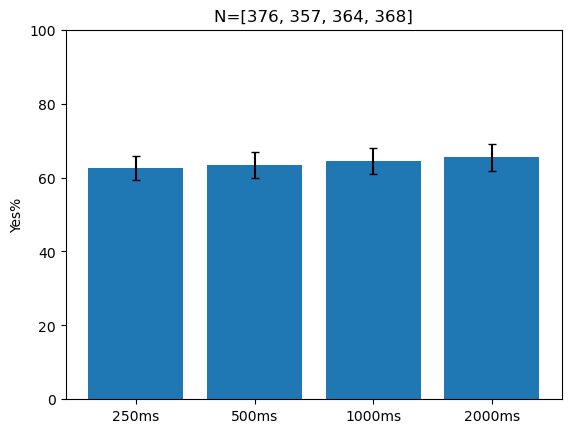

In [19]:
allyesratios = []
allyessems = []
sample_sizes = []
for icond, cond in enumerate(conditions):
    conddf = alldata[alldata['condition'] == cond]
    yesratios = []
    sample_sizes.append(conddf.shape[0])
    for scene in scenes:
        # print(f"scene {scene}")
        for prop in property_dict[scene].keys():
            (yescol, yesrank, nocol, _, shortname) = property_dict[scene][prop]
            tmpdf = conddf[conddf['scene'] == scene]
            yescount = tmpdf[yescol].notna().sum()
            yesratio = yescount / tmpdf.shape[0]*100 if tmpdf.shape[0]>0 else 0
            yesratios.append(yesratio)
            nocount = tmpdf[nocol].notna().sum()
            noratio = nocount / tmpdf.shape[0] if tmpdf.shape[0]>0 else 0
            assert yescount + nocount == tmpdf.shape[0]
            # print(f"\t{shortname}:\tyesratio={yesratio},\tnoratio={noratio}")
    print(f"condition yes: {np.mean(yesratios)} (sem={sem(yesratios)})")
    allyesratios.append(np.mean(yesratios))
    allyessems.append(sem(yesratios))
plt.bar(x=range(len(conditions)), height=allyesratios, yerr=allyessems, capsize=3)
plt.xticks(range(len(conditions)), conditions)
plt.ylim(0,100)
plt.ylabel('Yes%')
plt.title(f"N={sample_sizes}")

# Yes ~ Property ~ Condition

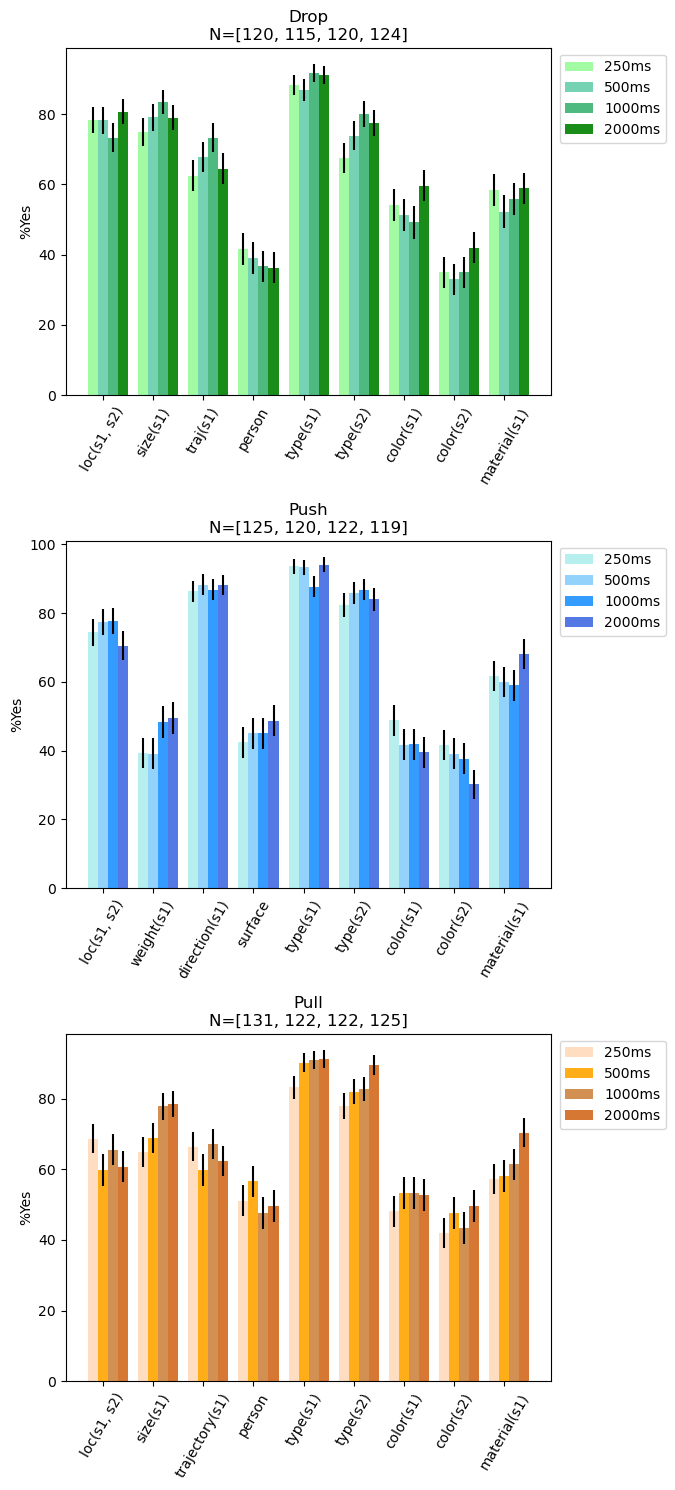

In [20]:
# Prepare figure for subplots
nrows = len(scenes)
fig, axs = plt.subplots(nrows, 1, figsize=(7, 5*nrows))
width = 0.4

for isc, scene in enumerate(scenes):
    sample_sizes = []
    for ic, condition in enumerate(conditions):
        tmpdf = alldata[(alldata['scene'] == scene) & (alldata['condition']== condition)]
        condratios = []
        condsems = []
        condprops = []
        for prop in property_dict[scene].keys():
            (yescol, yesrank, nocol, _, shortname) = property_dict[scene][prop]
            yescount = np.array(tmpdf[yescol].notna().tolist()) *100
            yesratio = np.mean(yescount)
            nocount = np.array(tmpdf[nocol].notna().tolist()) *100
            noratio = np.mean(nocount)
            condratios.append(yesratio)
            condsems.append(sem(yescount))
            condprops.append(shortname)
        sample_sizes.append(tmpdf.shape[0])
        condsems = [sem if not np.isnan(sem) else 0 for sem in condsems]
        axs[isc].bar(np.array(range(len(condprops)))*2 + width*(ic-1),
                    height=condratios,
                    yerr=condsems,
                    width=width,
                    color=colors_conditions[ic][isc], alpha=0.9,
                    label=condition)
        axs[isc].set_xticks(np.array(range(len(condprops)))*2, condprops, rotation=60)
        axs[isc].legend(loc="upper right", bbox_to_anchor=(1.25, 1.0))
    axs[isc].set_title(f"{scene}\nN={sample_sizes}")
    axs[isc].set_ylabel('%Yes')
plt.tight_layout()
plt.show()

# Rank Count ~ Property ~ Condition

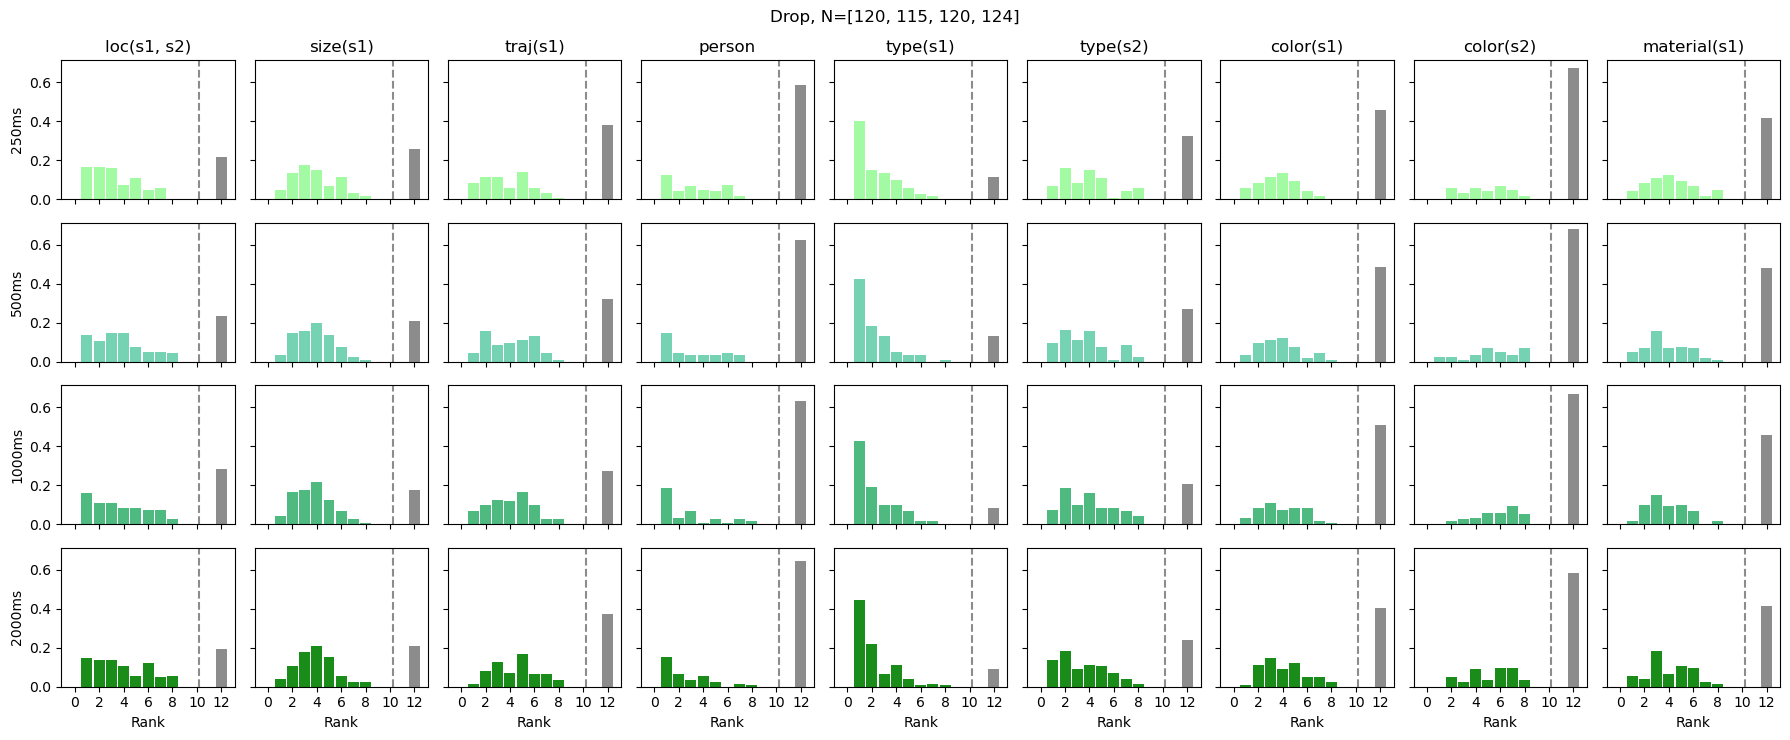

In [21]:
isc = 0
width = 0.9
scene = scenes[isc]
nprop = ncol = len(property_dict[scene].keys())
ncond = nrow = len(conditions)
fig, axs = plt.subplots(nrow, ncol, figsize=(2*ncol, 2.5*nrows), sharey=True, sharex=True)

for ip, (prop, vtuple) in enumerate(property_dict[scene].items()):
    sample_sizes = []
    for ic, condition in enumerate(conditions):
        tmpdf = alldata[(alldata['scene'] == scene) & (alldata['condition'] == condition)]
        sample_sizes.append(tmpdf.shape[0])
        hist = np.zeros(nprop+1)

        rank = np.where(tmpdf[vtuple[0]].notna(), tmpdf[vtuple[1]], -1)
        rank = np.array(rank, dtype=int)
        for r in rank:
            hist[r] += 1
        hist /= tmpdf.shape[0]

        labels = np.array(range(len(rank)*2), dtype=int)+1
        labels = list(labels)
        labels[len(rank):-1] = [""]*(len(rank)-1)
        labels[-1] = "No"
        axs[ic][ip].bar(np.array(range(len(hist[:-1]))),
                    height=hist[:-1],
                    width=width,
                    color=colors_conditions[ic][isc], alpha=0.9,
                    label=condition)
        axs[ic][ip].bar(len(hist)*1.2,
                    height=hist[-1],
                    width=width,
                    color='gray', alpha=0.9,
                    label=condition)
        axs[ic][ip].axvline(x=len(hist)*1.2-width*2, ls='--', color='gray', alpha=0.9)
        axs[ic][ip].xaxis.set_major_locator(MaxNLocator(integer=True))
        axs[0][ip].set_title(vtuple[-1])
        axs[-1][ip].set_xlabel('Rank')
        axs[ic][0].set_ylabel(condition)

plt.suptitle(f"{scene}, N={sample_sizes}")
plt.tight_layout()
plt.show()


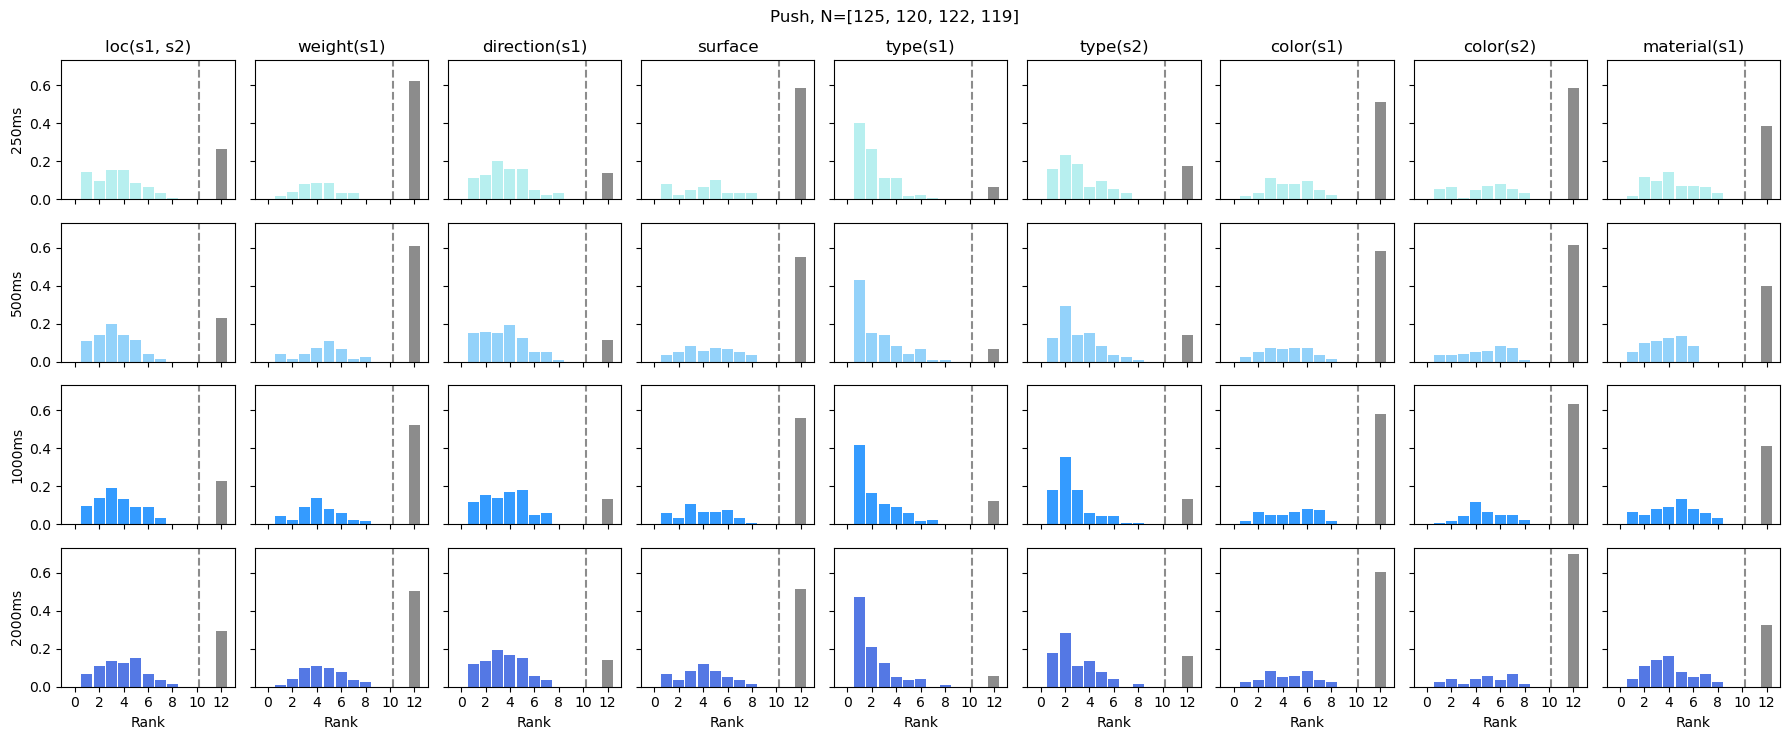

In [22]:
isc = 1
width = 0.9
scene = scenes[isc]
nprop = ncol = len(property_dict[scene].keys())
ncond = nrow = len(conditions)
fig, axs = plt.subplots(nrow, ncol, figsize=(2*ncol, 2.5*nrows), sharey=True, sharex=True)

for ip, (prop, vtuple) in enumerate(property_dict[scene].items()):
    sample_sizes = []
    for ic, condition in enumerate(conditions):
        tmpdf = alldata[(alldata['scene'] == scene) & (alldata['condition'] == condition)]
        sample_sizes.append(tmpdf.shape[0])
        hist = np.zeros(nprop+1)

        rank = np.where(tmpdf[vtuple[0]].notna(), tmpdf[vtuple[1]], -1)
        rank = np.array(rank, dtype=int)
        for r in rank:
            hist[r] += 1
        hist /= tmpdf.shape[0]

        labels = np.array(range(len(rank)*2), dtype=int)+1
        labels = list(labels)
        labels[len(rank):-1] = [""]*(len(rank)-1)
        labels[-1] = "No"
        axs[ic][ip].bar(np.array(range(len(hist[:-1]))),
                    height=hist[:-1],
                    width=width,
                    color=colors_conditions[ic][isc], alpha=0.9,
                    label=condition)
        axs[ic][ip].bar(len(hist)*1.2,
                    height=hist[-1],
                    width=width,
                    color='gray', alpha=0.9,
                    label=condition)
        axs[ic][ip].axvline(x=len(hist)*1.2-width*2, ls='--', color='gray', alpha=0.9)
        axs[ic][ip].xaxis.set_major_locator(MaxNLocator(integer=True))
        axs[0][ip].set_title(vtuple[-1])
        axs[-1][ip].set_xlabel('Rank')
        axs[ic][0].set_ylabel(condition)

plt.suptitle(f"{scene}, N={sample_sizes}")
plt.tight_layout()
plt.show()


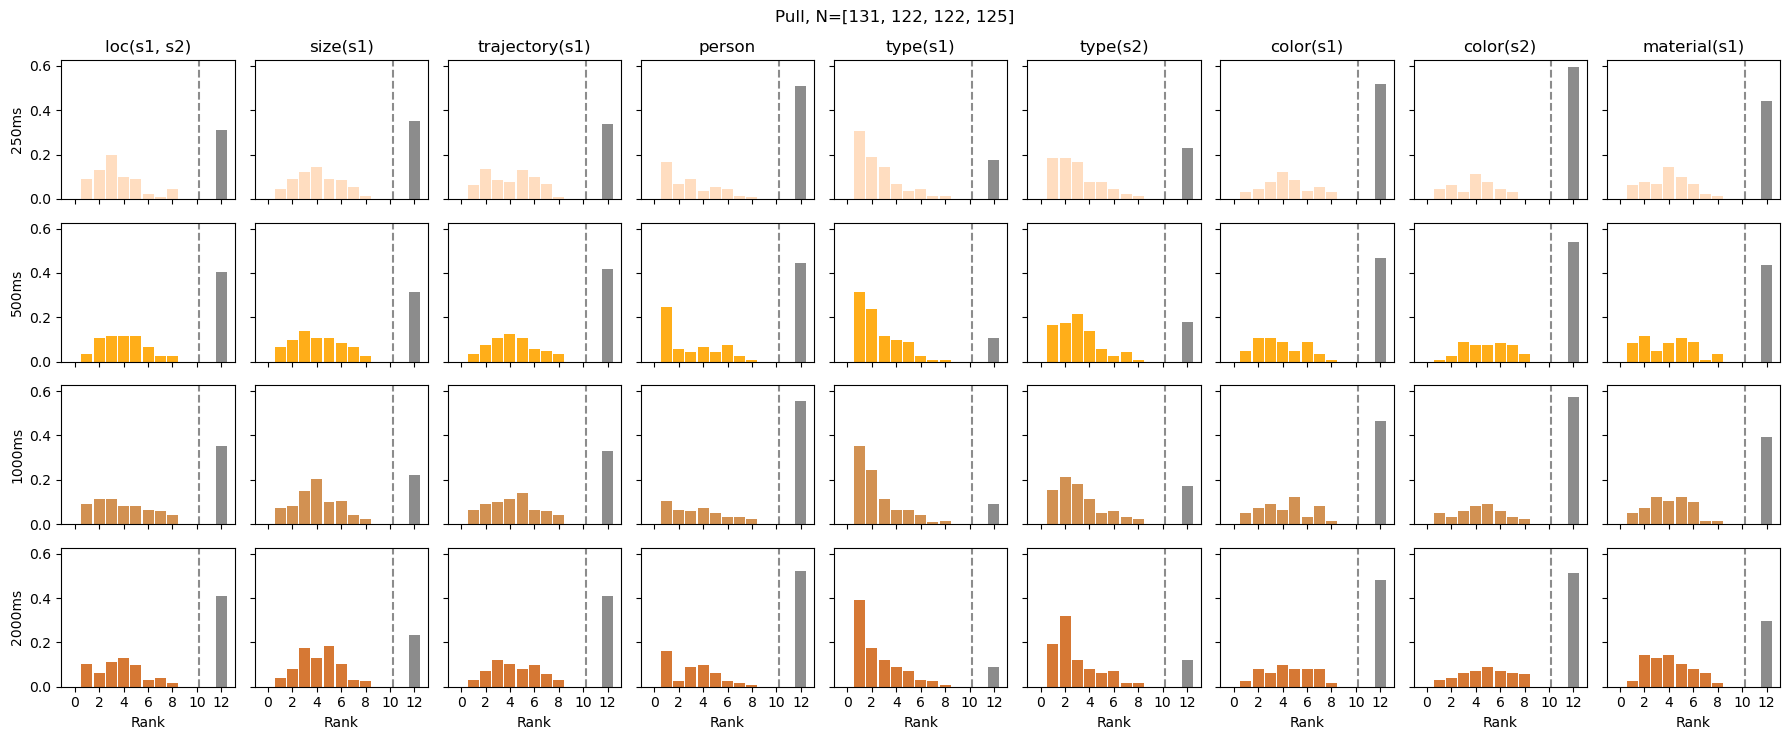

In [23]:
isc = 2
width = 0.9
scene = scenes[isc]
nprop = ncol = len(property_dict[scene].keys())
ncond = nrow = len(conditions)
fig, axs = plt.subplots(nrow, ncol, figsize=(2*ncol, 2.5*nrows), sharey=True, sharex=True)

for ip, (prop, vtuple) in enumerate(property_dict[scene].items()):
    sample_sizes = []
    for ic, condition in enumerate(conditions):
        tmpdf = alldata[(alldata['scene'] == scene) & (alldata['condition'] == condition)]
        sample_sizes.append(tmpdf.shape[0])
        hist = np.zeros(nprop+1)

        rank = np.where(tmpdf[vtuple[0]].notna(), tmpdf[vtuple[1]], -1)
        rank = np.array(rank, dtype=int)
        for r in rank:
            hist[r] += 1
        hist /= tmpdf.shape[0]

        labels = np.array(range(len(rank)*2), dtype=int)+1
        labels = list(labels)
        labels[len(rank):-1] = [""]*(len(rank)-1)
        labels[-1] = "No"
        axs[ic][ip].bar(np.array(range(len(hist[:-1]))),
                    height=hist[:-1],
                    width=width,
                    color=colors_conditions[ic][isc], alpha=0.9,
                    label=condition)
        axs[ic][ip].bar(len(hist)*1.2,
                    height=hist[-1],
                    width=width,
                    color='gray', alpha=0.9,
                    label=condition)
        axs[ic][ip].axvline(x=len(hist)*1.2-width*2, ls='--', color='gray', alpha=0.9)
        axs[ic][ip].xaxis.set_major_locator(MaxNLocator(integer=True))
        axs[0][ip].set_title(vtuple[-1])
        axs[-1][ip].set_xlabel('Rank')
        axs[ic][0].set_ylabel(condition)

plt.suptitle(f"{scene}, N={sample_sizes}")
plt.tight_layout()
plt.show()


# Rank ~ Property

In [24]:
replace_no = 10

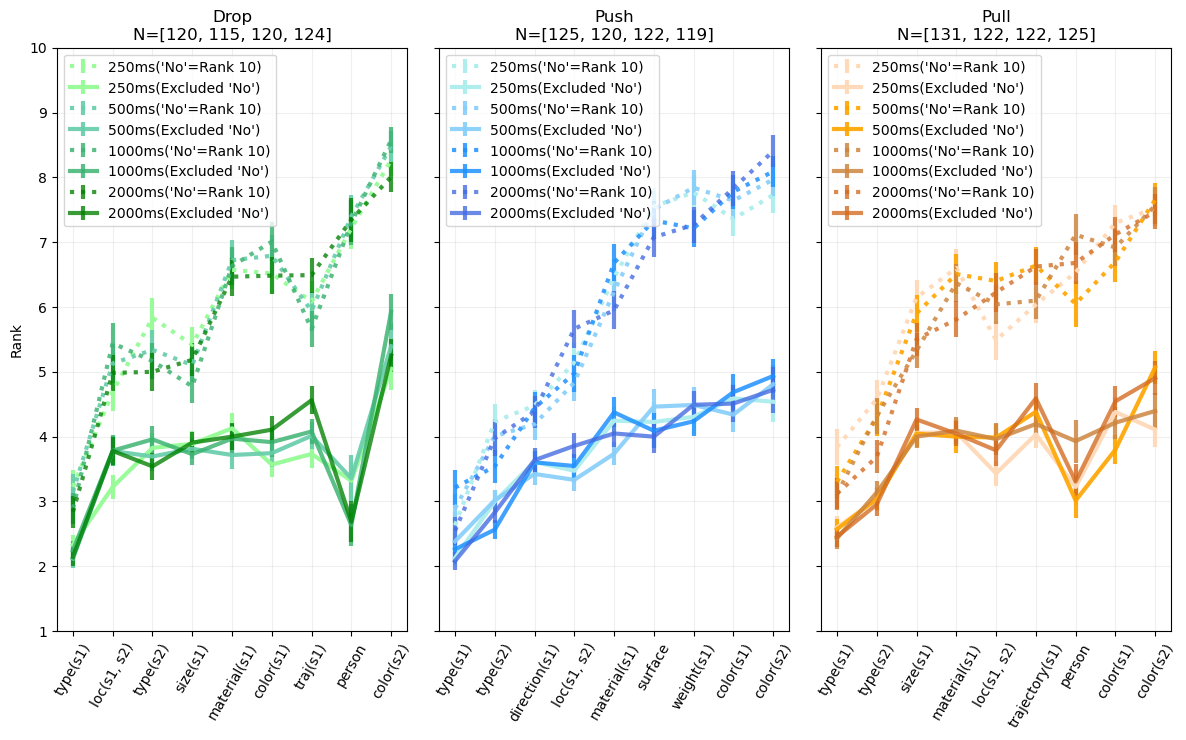

In [25]:
nprop = len(property_dict[scene].keys())
ncond  = len(conditions)
nrow = 1
nscenes = ncol = len(scenes)
fig, axs = plt.subplots(nrow, ncol, figsize=(4*ncol, 2.5*nrows), sharey=True)

xticks = []
for isc in range(len(scenes)):
    scene = scenes[isc]
    prop_names_allcond = []
    prop_rankavg_allcond_replace = []
    prop_ranksem_allcond_replace = []
    prop_rankavg_allcond_exclude = []
    prop_ranksem_allcond_exclude = []
    sample_sizes = []
    for ic, condition in enumerate(conditions):
        tmpdf = alldata[(alldata['scene'] == scene) & (alldata['condition'] == condition)]
        sample_sizes.append(tmpdf.shape[0])
        prop_names = []
        prop_rankavg_replace = []
        prop_ranksem_replace = []
        prop_rankavg_exclude = []
        prop_ranksem_exclude = []
        for ip, (prop, vtuple) in enumerate(property_dict[scene].items()):
            # get rank value if yes, rank=-1 if no
            rank = np.where(tmpdf[vtuple[0]].notna(), tmpdf[vtuple[1]], -1)
            prop_names.append(vtuple[-1])
            # replace no by another value
            rank_replace = np.array(rank, dtype=int)
            rank_replace[rank_replace == -1] = replace_no
            rankavg_replace = rank_replace.mean()
            ranksem_replace = sem(rank_replace)
            prop_rankavg_replace.append(rankavg_replace)
            prop_ranksem_replace.append(ranksem_replace)
            # exclude no responses
            rank_exclude = np.array(rank, dtype=int)
            rank_exclude = rank_exclude[rank_exclude != -1]
            rankavg_exclude = rank_exclude.mean()
            ranksem_exclude = sem(rank_exclude)
            prop_rankavg_exclude.append(rankavg_exclude)
            prop_ranksem_exclude.append(ranksem_exclude)
        prop_names_allcond = prop_names
        prop_rankavg_allcond_replace.append(prop_rankavg_replace)
        prop_ranksem_allcond_replace.append(prop_ranksem_replace)
        prop_rankavg_allcond_exclude.append(prop_rankavg_exclude)
        prop_ranksem_allcond_exclude.append(prop_ranksem_exclude)
    prop_rankavg_allcond_replace = np.array(prop_rankavg_allcond_replace, dtype=np.float32)
    prop_ranksem_allcond_replace = np.array(prop_ranksem_allcond_replace, dtype=np.float32)
    prop_rankavg_allcond_exclude = np.array(prop_rankavg_allcond_exclude, dtype=np.float32)
    prop_ranksem_allcond_exclude = np.array(prop_ranksem_allcond_exclude, dtype=np.float32)
    # sort x indices
    # sorted_indices = np.argsort(prop_rankavg_allcond_exclude[-1])
    sorted_indices = np.argsort(prop_rankavg_allcond_replace[-1])
    for ic, condition in enumerate(conditions):
        axs[isc].errorbar(x=range(len(prop_names_allcond)),
                          y=prop_rankavg_allcond_replace[ic][sorted_indices],
                          yerr=prop_ranksem_allcond_replace[ic][sorted_indices],
                          color=colors_conditions[ic][isc], alpha=(0.99**(ic*8+1)),
                          lw=3, ls=':',
                          label=condition+f"('No'=Rank {replace_no})")
        axs[isc].errorbar(x=range(len(prop_names_allcond)),
                          y=prop_rankavg_allcond_exclude[ic][sorted_indices],
                          yerr=prop_ranksem_allcond_exclude[ic][sorted_indices],
                          color=colors_conditions[ic][isc], alpha=(0.99**(ic*8+1)),
                          lw=3,
                          label=condition+"(Excluded 'No')")
    axs[0].set_ylabel('Rank')
    axs[isc].legend(loc='upper left')
    axs[isc].set_xticks(ticks=range(len(prop_names_allcond)), labels=np.array(prop_names_allcond)[sorted_indices], rotation=60)
    axs[isc].set_title(f"{scene}\nN={sample_sizes}")
    axs[isc].grid(which='both', alpha=0.2)

plt.ylim(1, max(7, replace_no))
plt.tight_layout()
plt.show()


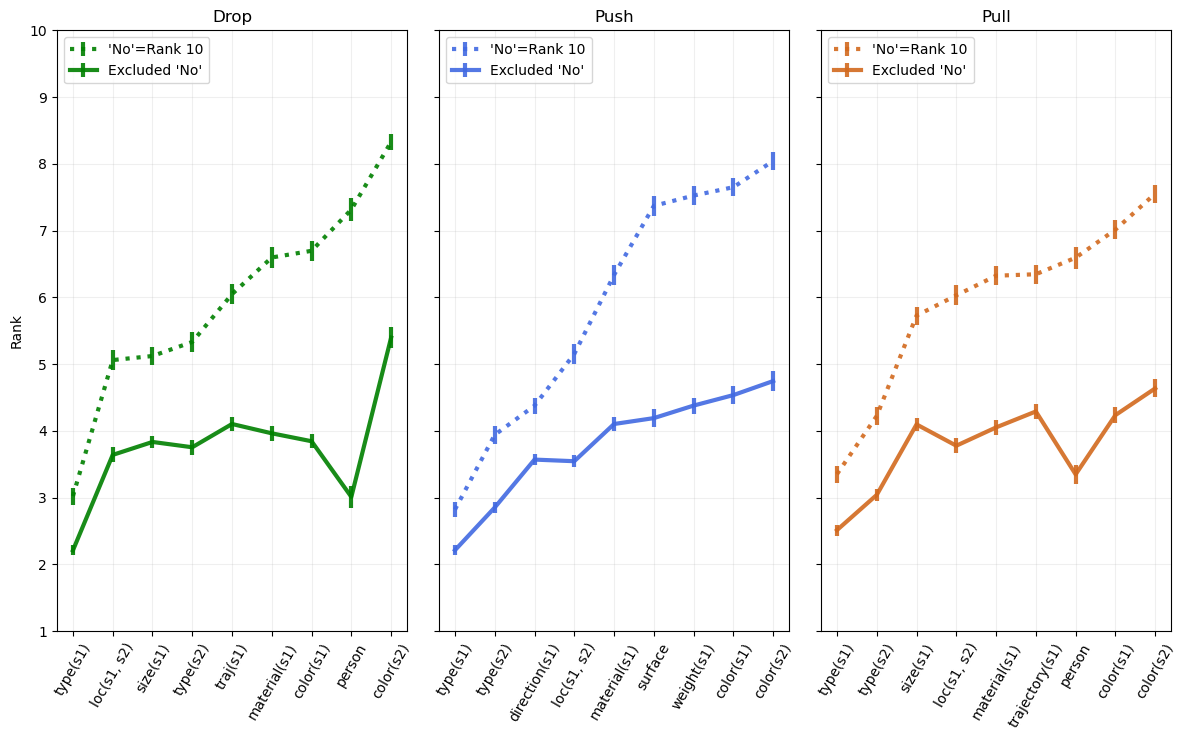

In [26]:
nprop = len(property_dict[scene].keys())
ncond  = len(conditions)
nrow = 1
nscenes = ncol = len(scenes)
fig, axs = plt.subplots(nrow, ncol, figsize=(4*ncol, 2.5*nrows), sharey=True)
sorted_indices_records = []


xticks = []
for isc in range(len(scenes)):
    scene = scenes[isc]
    prop_names_all = []
    prop_rankavg_allprop_replace = []
    prop_ranksem_allprop_replace =[]
    prop_rankavg_allprop_exclude = []
    prop_ranksem_allprop_exclude =[]
    for ip, (prop, vtuple) in enumerate(property_dict[scene].items()):
        prop_rank_replace = []
        prop_rank_exclude = []
        for ic, condition in enumerate(conditions):
            tmpdf = alldata[(alldata['scene'] == scene) & (alldata['condition'] == condition)]
            rank = np.where(tmpdf[vtuple[0]].notna(), tmpdf[vtuple[1]], -1) # get rank value if yes, otherwise rank=-1
            # replace no by another value
            rank_replace = np.array(rank, dtype=int)
            rank_replace[rank_replace == -1] = replace_no
            [prop_rank_replace.append(yr) for yr in rank_replace]
            # exclude no responses
            rank_exclude = np.array(rank, dtype=int)
            rank_exclude = rank_exclude[rank_exclude != -1]
            [prop_rank_exclude.append(yr) for yr in rank_exclude]
        prop_names_all.append(vtuple[-1])
        prop_rankavg_allprop_replace.append(np.mean(prop_rank_replace))
        prop_ranksem_allprop_replace.append(sem(prop_rank_replace))
        prop_rankavg_allprop_exclude.append(np.mean(prop_rank_exclude))
        prop_ranksem_allprop_exclude.append(sem(prop_rank_exclude))
    prop_rankavg_allprop_replace = np.array(prop_rankavg_allprop_replace, dtype=np.float32)
    prop_ranksem_allprop_replace = np.array(prop_ranksem_allprop_replace, dtype=np.float32)
    prop_rankavg_allprop_exclude = np.array(prop_rankavg_allprop_exclude, dtype=np.float32)
    prop_ranksem_allprop_exclude = np.array(prop_ranksem_allprop_exclude, dtype=np.float32)
    # sort x indices
    # sorted_indices = np.argsort(prop_rankavg_allprop_exclude)
    sorted_indices = np.argsort(prop_rankavg_allprop_replace)
    sorted_indices_records.append(sorted_indices)
    axs[isc].errorbar(x=range(len(prop_names_all)),
                      y=prop_rankavg_allprop_replace[sorted_indices],
                      yerr=prop_ranksem_allprop_replace[sorted_indices],
                      color=colors_conditions[-1][isc], alpha=0.9,
                      lw=3, ls=':',
                      label=f"'No'=Rank {replace_no}")
    axs[isc].errorbar(x=range(len(prop_names_all)),
                      y=prop_rankavg_allprop_exclude[sorted_indices],
                      yerr=prop_ranksem_allprop_exclude[sorted_indices],
                      color=colors_conditions[-1][isc], alpha=0.9,
                      lw=3,
                      label="Excluded 'No'")
    axs[isc].legend(loc='upper left')
    axs[0].set_ylabel('Rank')
    axs[isc].set_xticks(ticks=range(len(prop_names_all)), labels=np.array(prop_names_all)[sorted_indices], rotation=60)
    axs[isc].set_title(f"{scene}")
    axs[isc].grid(which='both', alpha=0.2)

plt.ylim(1,max(7, replace_no))
plt.tight_layout()
plt.show()


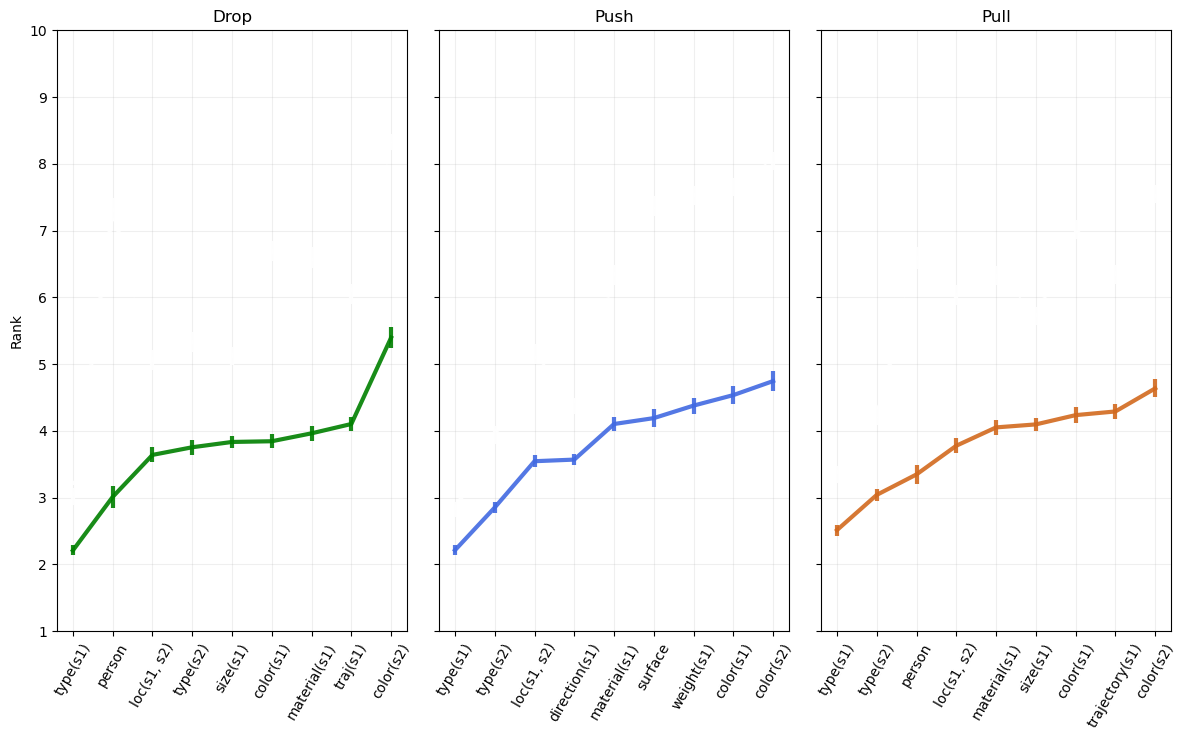

In [27]:
nprop = len(property_dict[scene].keys())
ncond  = len(conditions)
nrow = 1
nscenes = ncol = len(scenes)
fig, axs = plt.subplots(nrow, ncol, figsize=(4*ncol, 2.5*nrows), sharey=True)

xticks = []
for isc in range(len(scenes)):
    scene = scenes[isc]
    prop_names_all = []
    prop_rankavg_allprop_replace = []
    prop_ranksem_allprop_replace =[]
    prop_rankavg_allprop_exclude = []
    prop_ranksem_allprop_exclude =[]
    for ip, (prop, vtuple) in enumerate(property_dict[scene].items()):
        prop_rank_replace = []
        prop_rank_exclude = []
        for ic, condition in enumerate(conditions):
            tmpdf = alldata[(alldata['scene'] == scene) & (alldata['condition'] == condition)]
            rank = np.where(tmpdf[vtuple[0]].notna(), tmpdf[vtuple[1]], -1) # get rank value if yes, otherwise rank=-1
            # replace no by another value
            rank_replace = np.array(rank, dtype=int)
            rank_replace[rank_replace == -1] = replace_no
            [prop_rank_replace.append(yr) for yr in rank_replace]
            # exclude no responses
            rank_exclude = np.array(rank, dtype=int)
            rank_exclude = rank_exclude[rank_exclude != -1]
            [prop_rank_exclude.append(yr) for yr in rank_exclude]
        prop_names_all.append(vtuple[-1])
        prop_rankavg_allprop_replace.append(np.mean(prop_rank_replace))
        prop_ranksem_allprop_replace.append(sem(prop_rank_replace))
        prop_rankavg_allprop_exclude.append(np.mean(prop_rank_exclude))
        prop_ranksem_allprop_exclude.append(sem(prop_rank_exclude))
    prop_rankavg_allprop_replace = np.array(prop_rankavg_allprop_replace, dtype=np.float32)
    prop_ranksem_allprop_replace = np.array(prop_ranksem_allprop_replace, dtype=np.float32)
    prop_rankavg_allprop_exclude = np.array(prop_rankavg_allprop_exclude, dtype=np.float32)
    prop_ranksem_allprop_exclude = np.array(prop_ranksem_allprop_exclude, dtype=np.float32)
    # sort x indices
    sorted_indices = np.argsort(prop_rankavg_allprop_exclude)
    axs[isc].errorbar(x=range(len(prop_names_all)),
                      y=prop_rankavg_allprop_replace[sorted_indices],
                      yerr=prop_ranksem_allprop_replace[sorted_indices],
                      color='white', alpha=0.9,
                      lw=3, ls=':',
                      label=f"'No'=Rank {replace_no}")
    axs[isc].errorbar(x=range(len(prop_names_all)),
                      y=prop_rankavg_allprop_exclude[sorted_indices],
                      yerr=prop_ranksem_allprop_exclude[sorted_indices],
                      color=colors_conditions[-1][isc], alpha=0.9,
                      lw=3,
                      label="Excluded 'No'")
    # axs[isc].legend(loc='upper left')
    axs[0].set_ylabel('Rank')
    axs[isc].set_xticks(ticks=range(len(prop_names_all)), labels=np.array(prop_names_all)[sorted_indices], rotation=60)
    axs[isc].set_title(f"{scene}")
    axs[isc].grid(which='both', alpha=0.2)

plt.ylim(1,max(7, replace_no))
plt.tight_layout()
plt.show()


# Main Plot

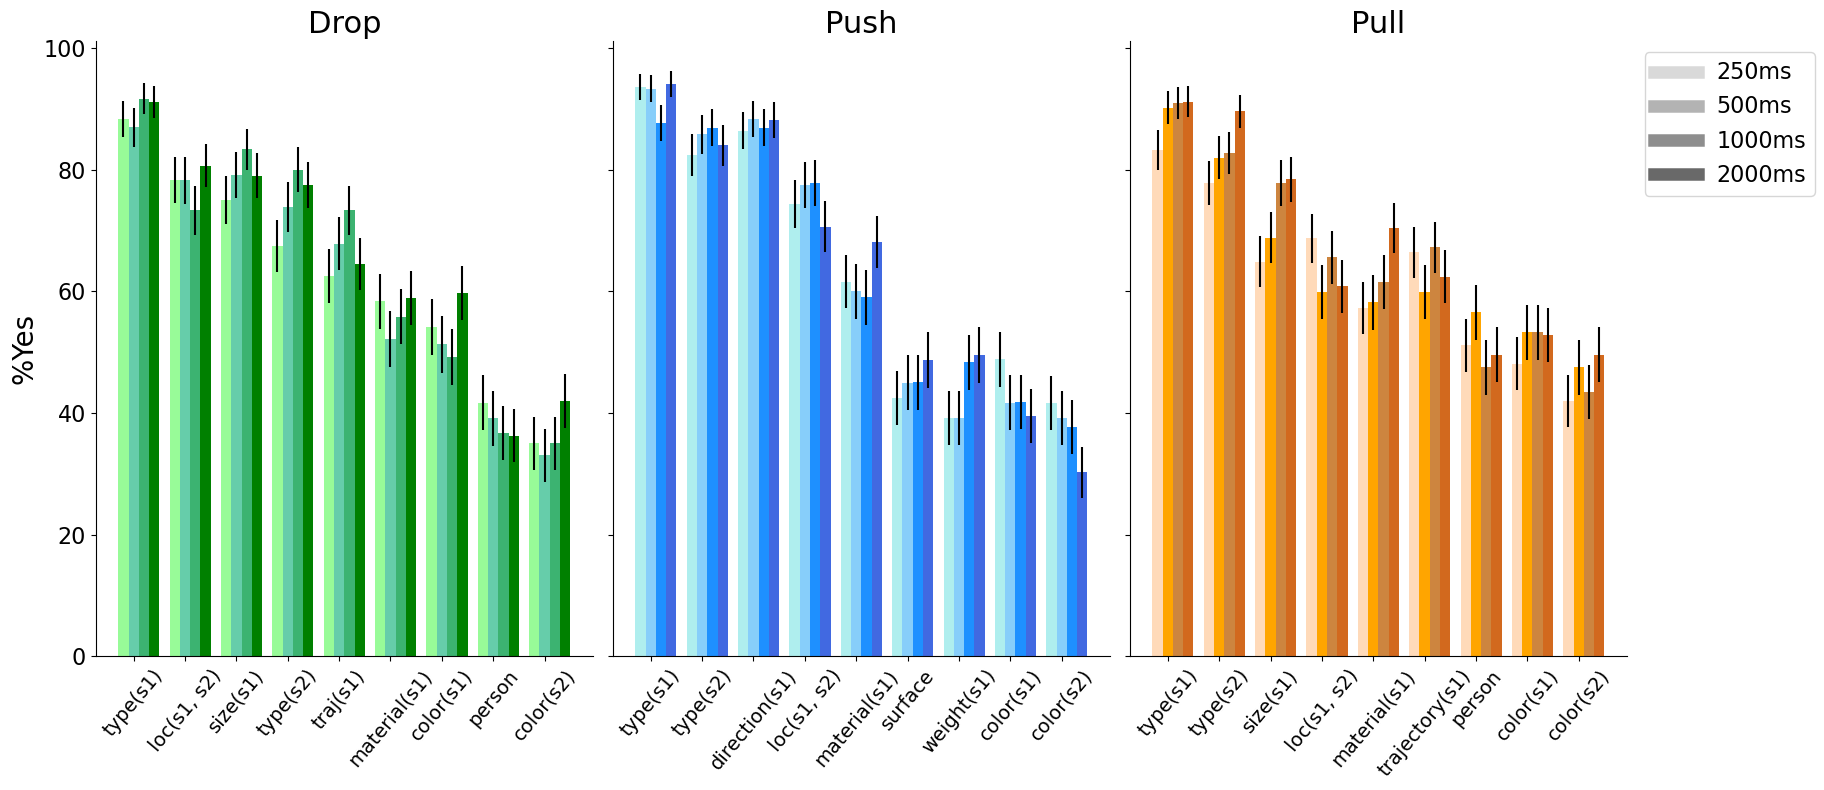

In [28]:
width = 0.4
ncols = len(scenes)
fig, axs = plt.subplots(1, ncols, figsize=(6*ncols, 8), sharey=True)

for isc, scene in enumerate(scenes):
    sample_sizes = []
    for ic, condition in enumerate(conditions):
        tmpdf = alldata[(alldata['scene'] == scene) & (alldata['condition']== condition)]
        condratios = []
        condsems = []
        condprops = []
        sorted_indices = sorted_indices_records[isc]
        sorted_props = np.array(list(property_dict[scene].keys()))[sorted_indices]
        for prop in sorted_props:
            (yescol, yesrank, nocol, _, shortname) = property_dict[scene][prop]
            yescount = np.array(tmpdf[yescol].notna().tolist()) *100
            yesratio = np.mean(yescount)
            nocount = np.array(tmpdf[nocol].notna().tolist()) *100
            noratio = np.mean(nocount)
            condratios.append(yesratio)
            condsems.append(sem(yescount))
            condprops.append(shortname)
        sample_sizes.append(tmpdf.shape[0])
        condsems = [sem if not np.isnan(sem) else 0 for sem in condsems]
        axs[isc].bar(np.array(range(len(condprops)))*2 + width*(ic-1),
                    height=condratios,
                    yerr=condsems,
                    width=width,
                    color=colors_conditions[ic][isc], alpha=1,
                    label=condition)
        axs[isc].set_xticks(np.array(range(len(condprops)))*2, condprops, rotation=50)
    axs[isc].set_title(f"{scene}", fontsize=22)
    axs[isc].tick_params(axis='x', labelsize=14)
    axs[isc].tick_params(axis='y', labelsize=16)
    axs[isc].spines['right'].set_visible(False)
    axs[isc].spines['top'].set_visible(False)
axs[0].set_ylabel('%Yes', fontsize=20)
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color="dimgray", alpha=0.25*(ic+1), lw=9, label=conditions[ic]) for ic, condition in enumerate(conditions)]
axs[-1].legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(1.4, 1.0), fontsize=16)
plt.tight_layout()
plt.show()

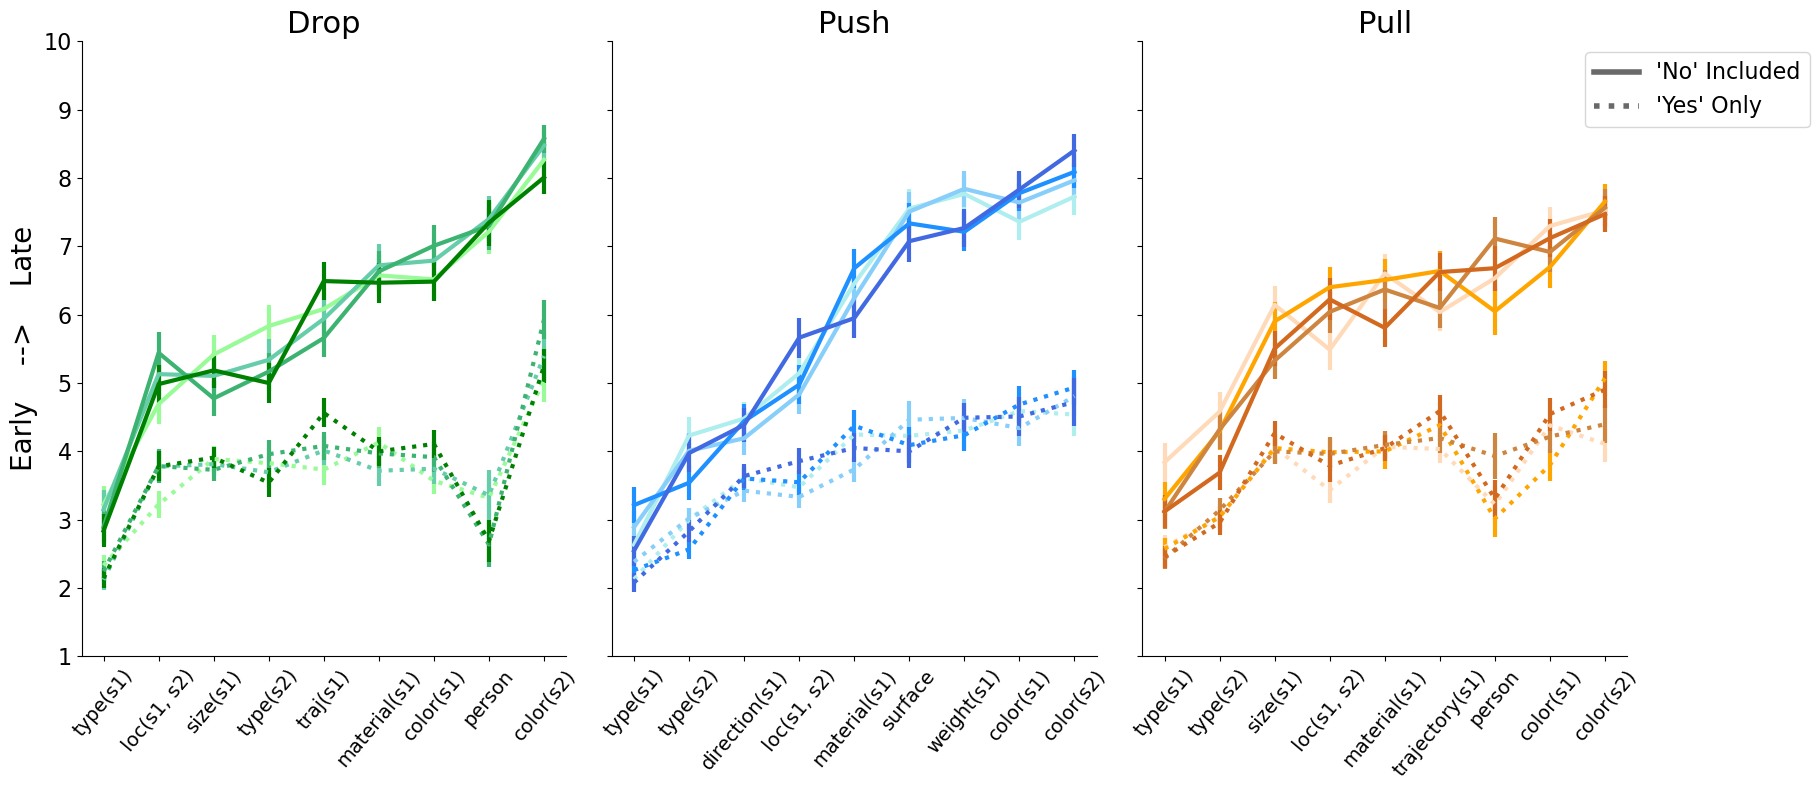

In [29]:
replace_no = 10
nprop = len(property_dict[scene].keys())
ncond  = len(conditions)
nscenes = ncol = len(scenes)
fig, axs = plt.subplots(1, ncol, figsize=(6*ncol, 8), sharey=True)

xticks = []
for isc in range(len(scenes)):
    scene = scenes[isc]
    prop_names_allcond = []
    prop_rankavg_allcond_replace = []
    prop_ranksem_allcond_replace = []
    prop_rankavg_allcond_exclude = []
    prop_ranksem_allcond_exclude = []
    sample_sizes = []
    for ic, condition in enumerate(conditions):
        tmpdf = alldata[(alldata['scene'] == scene) & (alldata['condition'] == condition)]
        sample_sizes.append(tmpdf.shape[0])
        prop_names = []
        prop_rankavg_replace = []
        prop_ranksem_replace = []
        prop_rankavg_exclude = []
        prop_ranksem_exclude = []
        for ip, (prop, vtuple) in enumerate(property_dict[scene].items()):
            # get rank value if yes, rank=-1 if no
            rank = np.where(tmpdf[vtuple[0]].notna(), tmpdf[vtuple[1]], -1)
            prop_names.append(vtuple[-1])
            # replace no by another value
            rank_replace = np.array(rank, dtype=int)
            rank_replace[rank_replace == -1] = replace_no
            rankavg_replace = rank_replace.mean()
            ranksem_replace = sem(rank_replace)
            prop_rankavg_replace.append(rankavg_replace)
            prop_ranksem_replace.append(ranksem_replace)
            # exclude no responses
            rank_exclude = np.array(rank, dtype=int)
            rank_exclude = rank_exclude[rank_exclude != -1]
            rankavg_exclude = rank_exclude.mean()
            ranksem_exclude = sem(rank_exclude)
            prop_rankavg_exclude.append(rankavg_exclude)
            prop_ranksem_exclude.append(ranksem_exclude)
        prop_names_allcond = prop_names
        prop_rankavg_allcond_replace.append(prop_rankavg_replace)
        prop_ranksem_allcond_replace.append(prop_ranksem_replace)
        prop_rankavg_allcond_exclude.append(prop_rankavg_exclude)
        prop_ranksem_allcond_exclude.append(prop_ranksem_exclude)
    prop_rankavg_allcond_replace = np.array(prop_rankavg_allcond_replace, dtype=np.float32)
    prop_ranksem_allcond_replace = np.array(prop_ranksem_allcond_replace, dtype=np.float32)
    prop_rankavg_allcond_exclude = np.array(prop_rankavg_allcond_exclude, dtype=np.float32)
    prop_ranksem_allcond_exclude = np.array(prop_ranksem_allcond_exclude, dtype=np.float32)
    # sort x indices
    sorted_indices = sorted_indices_records[isc]
    for ic, condition in enumerate(conditions):
        axs[isc].errorbar(x=range(len(prop_names_allcond)),
                          y=prop_rankavg_allcond_replace[ic][sorted_indices],
                          yerr=prop_ranksem_allcond_replace[ic][sorted_indices],
                          color=colors_conditions[ic][isc],# alpha=(0.99**(ic*8+1)),
                          lw=3,
                          label=condition+f"('No'=Rank {replace_no})")
        axs[isc].errorbar(x=range(len(prop_names_allcond)),
                          y=prop_rankavg_allcond_exclude[ic][sorted_indices],
                          yerr=prop_ranksem_allcond_exclude[ic][sorted_indices],
                          color=colors_conditions[ic][isc], #alpha=(0.99**(ic*8+1)),
                          lw=3, ls=":",
                          label=condition+"(Excluded 'No')")
    axs[isc].set_title(f"{scene}", fontsize=22)
    axs[isc].set_xticks(ticks=range(len(prop_names_allcond)), labels=np.array(prop_names_allcond)[sorted_indices], rotation=50)
    axs[isc].spines['right'].set_visible(False)
    axs[isc].spines['top'].set_visible(False)
    axs[isc].tick_params(axis='x', labelsize=14)
    axs[isc].tick_params(axis='y', labelsize=16)

axs[0].set_ylabel('Early    -->    Late', fontsize=20)
legend_elements = [Line2D([0], [0], color="dimgray", lw=4, label="'No' Included"),
                   Line2D([0], [0], color="dimgray", lw=4, ls=":", label="'Yes' Only"),]
axs[-1].legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(1.4, 1.0), fontsize=16)
plt.ylim(1, max(7, replace_no))
plt.tight_layout()
plt.show()


In [30]:
alldata.shape

(1465, 91)

# Category Level Comparison

In [45]:
from scipy import stats
from statsmodels.stats.multicomp import MultiComparison
from itertools import combinations

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [46]:
def p_to_text(p: float) -> str:
    """Convert a p-value to ‘significance stars’."""
    if p < 0.001:
        return "***".format(p)
    elif p < 0.01:
        return "**".format(p)
    elif p < 0.05:
        return "*".format(p)
    else:
        return "NS"


In [47]:
prop_idx_to_category = {
    'Drop':
        {
        4: "A: Identity",
        5: "A: Identity",
        
        0: "B: Spatial/Physical",
        1: "B: Spatial/Physical",
        2: "B: Spatial/Physical",
        
        6: "C: Surface",
        7: "C: Surface",
        8: "C: Surface",
        
        3: "D: Person",
        },
        
    'Push':
        {
        4: "A: Identity",
        5: "A: Identity",
        
        0: "B: Spatial/Physical",
        1: "B: Spatial/Physical",
        2: "B: Spatial/Physical",
        
        6: "C: Surface",
        7: "C: Surface",
        8: "C: Surface",
        
        3: "D: Table/Floor",
        },
        
    'Pull':
        {
        4: "A: Identity",
        5: "A: Identity",
        
        0: "B: Spatial/Physical",
        1: "B: Spatial/Physical",
        2: "B: Spatial/Physical",
        
        6: "C: Surface",
        7: "C: Surface",
        8: "C: Surface",
        
        3: "D: Person",
        }
}

In [48]:
prop_idx_to_obj = {
	"Drop": {
		0: "Obj1&2",
		1: "Obj1",
		2: "Obj1",
		3: "Person",
		4: "Obj1",
		5: "Obj2",
		6: "Obj1",
		7: "Obj2",
		8: "Obj1",
	},
	"Push":{
		0: "Obj1&2",
		1: "Obj1",
		2: "Obj1",
		3: "Surface",
		4: "Obj1",
		5: "Obj2",
		6: "Obj1",
		7: "Obj2",
		8: "Obj1",
	},
	"Pull":{
		0: "Obj1&2",
		1: "Obj1",
		2: "Obj1",
		3: "Person",
		4: "Obj1",
		5: "Obj2",
		6: "Obj1",
		7: "Obj2",
		8: "Obj1",
	},
}

In [86]:
def wide_to_long(wide_df):
	long_rows: list[dict] = []
	for _, row in wide_df.iterrows():
		scene       = row["scene"]
		time_cond   = row["condition"]
		if time_cond == "250ms":
			time_cond = "0250ms"
		elif time_cond == "500ms":
			time_cond = "0500ms"
		participant = row[subidcol]
		for prop_idx, (prop_fullname, vtuple) in enumerate(property_dict[scene].items()):
			yes_col, rank_col, no_col, _, short_name = vtuple
			yes_flag = int(pd.notna(row[yes_col])) # 1 if yes, 0 if no
			rank_val = np.nan if yes_flag == 0 else int(row[rank_col])	
			assert pd.notna(row[no_col]) if yes_flag==0 else pd.isna(row[no_col])
			assert pd.isna(row[rank_col]) if yes_flag==0 else pd.notna(row[rank_col])
			long_rows.append(
				{
					"yes":	yes_flag,
					"rank":	rank_val, 
					"property":	 short_name, 
					"scene":       scene,
					"time":        time_cond,
					"participant": participant,
					"category":    prop_idx_to_category[scene][prop_idx],
					"object": prop_idx_to_obj[scene][prop_idx],
				}
			)

	long_df = pd.DataFrame(long_rows)
	assert not long_df.empty
	return long_df

long_df = wide_to_long(alldata)
long_df

In [92]:
long_df

## Avg Rank

data df shape (1465, 91)
Scene Drop one-way ANOVA: f=72.183, p=6.282e-45
Scene Push one-way ANOVA: f=160.172, p=9.646e-96
Scene Pull one-way ANOVA: f=103.347, p=1.430e-63
  scene                                         categories  \
0  Drop  [A: Identity, B: Spatial/Physical, C: Surface,...   
1  Push  [A: Identity, B: Spatial/Physical, C: Surface,...   
2  Pull  [A: Identity, B: Spatial/Physical, C: Surface,...   

   A: Identity_avg_rank  B: Spatial/Physical_avg_rank  C: Surface_avg_rank  \
0              2.912325                      3.847015             4.275321   
1              2.518605                      3.733068             4.401734   
2              2.768335                      4.056943             4.278894   

   D: Person_avg_rank  A: Identity_sem  B: Spatial/Physical_sem  \
0            3.010870         0.069512                 0.058245   
1                 NaN         0.054580                 0.056744   
2            3.347656         0.061624                 0.061172   

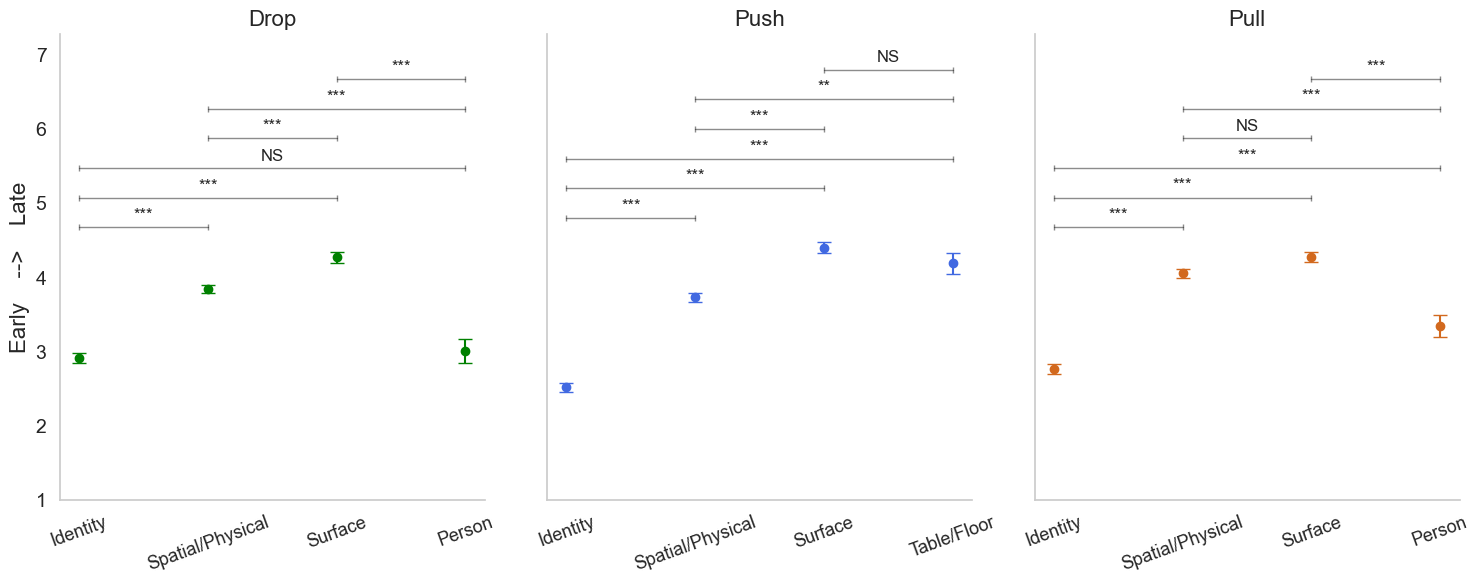

In [87]:
def analyze_category_ranks(df, prop_idx_to_category, property_dict, scenes):
    """Analyzes the average rank of properties, grouped into categories.

    Args:
        df: The DataFrame containing the data.
        property_dict: A dictionary mapping scene names to property details.
        scenes: A list of scene names.

    Returns:
        A DataFrame containing the average rank of each property category for each scene.
    """
    print(f"data df shape {df.shape}")
    results = []
    for scene in scenes:
        tmpdf = df[df['scene'] == scene]
        
        # Initialize dictionaries for each category
        categories = sorted(list(set(prop_idx_to_category[scene].values())))
        category_ranks = {cat: [] for cat in categories}
        
        # Collect ranks for each property
        for i, (prop, vtuple) in enumerate(property_dict[scene].items()):
            (yescol, yesrank, nocol, _, shortname) = vtuple
            rank = np.where(tmpdf[yescol].notna(), tmpdf[yesrank], np.nan)
            rank_exclude = rank[~np.isnan(rank)]
            category = prop_idx_to_category[scene][i]
            category_ranks[category].extend(rank_exclude)
            
        # Calculate averages and SEMs
        avg_ranks = {
            category: np.mean(ranks) if ranks else np.nan
            for category, ranks in category_ranks.items()
        }
        avg_rank_sems = {
            category: sem(ranks) if ranks else np.nan
            for category, ranks in category_ranks.items()
        }
        
        # Prep data for stats tests
        all_ranks = []
        all_categories = []
        for cat in categories:
            all_ranks.extend(category_ranks[cat])
            all_categories.extend([cat] * len(category_ranks[cat]))
        
        # One-way ANOVA
        f_stat, p_val = stats.f_oneway(*[category_ranks[cat] for cat in categories])
        print(f"Scene {scene} one-way ANOVA: f={f_stat:.3f}, p={p_val:.3e}")
        
        # Post-hoc Tukey test
        mc = MultiComparison(all_ranks, all_categories)
        tukey_result = mc.tukeyhsd()
        
        results.append({
            'scene': scene,
            'categories': categories,
            **{f'{cat}_avg_rank': avg_ranks[cat] for cat in categories},
            **{f'{cat}_sem': avg_rank_sems[cat] for cat in categories},
            'f_stat': f_stat,
            'p_val': p_val,
            'tukey_result': pd.DataFrame(
                    tukey_result._results_table.data[1:],
                    columns=tukey_result._results_table.data[0])
        })
        
    return pd.DataFrame(results)



results_df = analyze_category_ranks(alldata, prop_idx_to_category, property_dict, scenes)
print(results_df)



# Plotting
fig, axs = plt.subplots(1, len(scenes), figsize=(5 * len(scenes), 6), sharey=True)

for i, scene in enumerate(scenes):
    scene_df = results_df[results_df['scene'] == scene].iloc[0]
    categories = scene_df['categories']
    
    # Get average ranks and SEMs
    avg_ranks = [scene_df[f'{cat}_avg_rank'] for cat in categories]
    sems = [scene_df[f'{cat}_sem'] for cat in categories]
    
    # Plot error bars
    axs[i].errorbar(categories, avg_ranks, yerr=sems, fmt='o', capsize=5, linestyle='',
                    color=colors_conditions[-1][i])
    
    # Add statistical significance markers
    tukey_result = scene_df['tukey_result']
    y_max = max(avg_ranks) 
    
    # Plot significance bars
    for j, row in tukey_result.iterrows():
        cat1, cat2 = row["group1"], row["group2"]
        idx1, idx2 = idx1, idx2 = categories.index(cat1), categories.index(cat2)
        y_pos = y_max + 0.4 * (j + 1)
        axs[i].plot([idx1, idx2], [y_pos, y_pos], 'k-', lw=1, alpha=0.5, marker='|', markersize=4)
        p_value = row["p-adj"]
        significance = p_to_text(p_value)
        axs[i].text((idx1 + idx2)/2, y_pos + 0.1, significance, ha='center', fontsize=12)
    
    # final touch on plot
    axs[i].set_ylim(1, min(y_max + 3, 9))
    axs[i].set_xticks(range(len(categories)))
    axs[i].set_xticklabels([c[3:] for c in categories], rotation=20, fontsize=13)
    axs[i].set_title(f'{scene}', fontsize=16)
    axs[0].set_ylabel('Early    -->    Late', fontsize=16)
    axs[i].tick_params(axis='y', labelsize=14)
    # axs[len(scenes)//2].set_xlabel('Property Category', fontsize=16)
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['top'].set_visible(False)
    axs[i].grid(False)
    
plt.tight_layout()
plt.show()

## Yes Ratio

In [88]:
def analyze_category_yesratio(df, prop_idx_to_category, property_dict, scenes):
    results = []
    print(f"data df shape {df.shape}")
    for scene in scenes:
        tmpdf = df[df['scene'] == scene]
        
        # Initialize dictionaries for each category
        categories = sorted(list(set(prop_idx_to_category[scene].values())))
        category_yesno = {cat: [] for cat in categories}
        
        # Collect ranks for each property
        for i, (prop, vtuple) in enumerate(property_dict[scene].items()):
            (yescol, yesrank, nocol, _, shortname) = vtuple
            totalresponse = len(tmpdf[yescol])
            assert totalresponse==tmpdf[yescol].shape[0]
            nocount = tmpdf[yescol].isna().sum()
            yescount = totalresponse - nocount
            assert totalresponse >= yescount, f"totalresponse {totalresponse} should >= yescount {yescount}"
            
            category = prop_idx_to_category[scene][i]
            category_yesno[category].extend([0]*nocount)
            category_yesno[category].extend([1]*yescount)
            
        # Calculate averages and SEMs
        avg_yesratio = {
            category: np.mean(yesno) if yesno else np.nan
            for category, yesno in category_yesno.items()
        }
        avg_yesratio_sems = {
            category: sem(yesno) if yesno else np.nan
            for category, yesno in category_yesno.items()
        }
        
        # Prep data for stats tests
        all_yesno = []
        all_categories = []
        for cat in categories:
            all_yesno.extend(category_yesno[cat])
            all_categories.extend([cat] * len(category_yesno[cat]))
        
        # One-way ANOVA
        f_stat, p_val = stats.f_oneway(*[category_yesno[cat] for cat in categories])
        print(f"Scene {scene} one-way ANOVA: f={f_stat:.3f}, p={p_val:.3e}")
        
        # Post-hoc Tukey test
        mc = MultiComparison(all_yesno, all_categories)
        tukey_result = mc.tukeyhsd()
        
        results.append({
            'scene': scene,
            'categories': categories,
            **{f'{cat}_avg_yesratio': avg_yesratio[cat] for cat in categories},
            **{f'{cat}_sem': avg_yesratio_sems[cat] for cat in categories},
            'f_stat': f_stat,
            'p_val': p_val,
            'tukey_result': pd.DataFrame(
                    tukey_result._results_table.data[1:],
                    columns=tukey_result._results_table.data[0])
        })
        print(tukey_result)
        
    return pd.DataFrame(results)


results_df = analyze_category_yesratio(alldata, prop_idx_to_category, property_dict, scenes)


data df shape (1465, 91)
Scene Drop one-way ANOVA: f=182.135, p=3.470e-111
             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
       group1              group2       meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------------
        A: Identity B: Spatial/Physical  -0.0755 0.0004 -0.1241 -0.0269   True
        A: Identity          C: Surface  -0.3337    0.0 -0.3823 -0.2851   True
        A: Identity           D: Person  -0.4374    0.0 -0.5026 -0.3722   True
B: Spatial/Physical          C: Surface  -0.2582    0.0 -0.3016 -0.2147   True
B: Spatial/Physical           D: Person  -0.3619    0.0 -0.4233 -0.3004   True
         C: Surface           D: Person  -0.1037 0.0001 -0.1652 -0.0422   True
------------------------------------------------------------------------------
Scene Push one-way ANOVA: f=192.695, p=2.309e-117
             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      

/var/folders/qh/sj5zjwdx1l5dhhxcwzgwhtkc0000gn/T/ipykernel_1301/3736531554.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_yticklabels([f'{int(x*100)}' for x in axs[0].get_yticks()], fontsize=14)
/var/folders/qh/sj5zjwdx1l5dhhxcwzgwhtkc0000gn/T/ipykernel_1301/3736531554.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_yticklabels([f'{int(x*100)}' for x in axs[0].get_yticks()], fontsize=14)
/var/folders/qh/sj5zjwdx1l5dhhxcwzgwhtkc0000gn/T/ipykernel_1301/3736531554.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_yticklabels([f'{int(x*100)}' for x in axs[0].get_yticks()], fontsize=14)


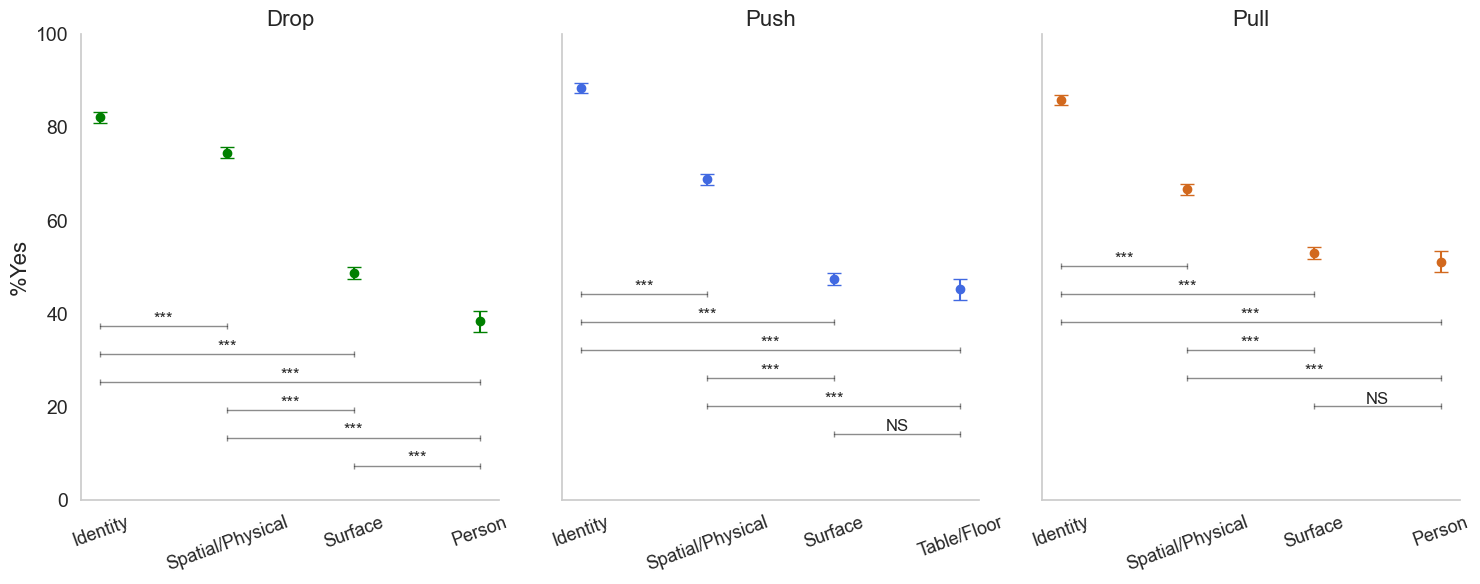

In [89]:
# Plotting
fig, axs = plt.subplots(1, len(scenes), figsize=(5 * len(scenes), 6), sharey=True)

for i, scene in enumerate(scenes):
    scene_df = results_df[results_df['scene'] == scene].iloc[0]
    categories = scene_df['categories']
    
    # Get average ranks and SEMs
    avg_yesratio = [scene_df[f'{cat}_avg_yesratio'] for cat in categories]
    sems = [scene_df[f'{cat}_sem'] for cat in categories]
    
    # Plot error bars
    axs[i].errorbar(categories, avg_yesratio, yerr=sems, fmt='o', capsize=5, linestyle='',
                    color=colors_conditions[-1][i])
    
    # Add statistical significance markers
    tukey_result = scene_df['tukey_result']
    y_min = min(avg_yesratio) + 0.05
    
    # Plot significance bars
    for j, row in tukey_result.iterrows():
        cat1, cat2 = row["group1"], row["group2"]
        idx1, idx2 = idx1, idx2 = categories.index(cat1), categories.index(cat2)
        y_pos = y_min - 0.06 * (j + 1)
        axs[i].plot([idx1, idx2], [y_pos, y_pos], 'k-', lw=1, alpha=0.5, marker='|', markersize=4)
        p_value = row["p-adj"]
        significance = p_to_text(p_value)
        axs[i].text((idx1 + idx2)/2, y_pos + 0.005, significance, ha='center', fontsize=12)
    
    # final touch on plot
    axs[i].set_ylim(0, 1)
    axs[i].set_xticks(range(len(categories)))
    axs[i].set_xticklabels([c[3:] for c in categories], rotation=20, fontsize=13)
    axs[i].set_title(f'{scene}', fontsize=16)
    axs[0].set_ylabel('%Yes', fontsize=16)
    axs[0].set_yticklabels([f'{int(x*100)}' for x in axs[0].get_yticks()], fontsize=14)
    # axs[len(scenes)//2].set_xlabel('Property Category', fontsize=16)
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['top'].set_visible(False)
    axs[i].grid(False)
    
plt.tight_layout()
plt.show()

# Logistic Regression

In [90]:
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

In [91]:
glm_df = long_df.copy()

if glm_df.empty:
    raise RuntimeError(
        "The long-format dataframe is empty.  Check that `property_dict` "
        "and the raw responses are correctly defined."
    )

# Ensure correct dtypes for the GLMM
glm_df["yes"] = glm_df["yes"].astype(int)        # binary 0 / 1
for col in ["property", "category", "time", "participant", "scene"]:
    glm_df[col] = glm_df[col].astype("category")

# Specify and fit the mixed-effect logistic regression.
formula_fixed = "yes ~ C(category) * C(time)"

# Random intercepts
vc_formula = {
    "participant": "0 + C(participant)",
    "property": "0 + C(property)",
    "scene": "0 + C(scene)",
}

print(
    "\nFitting mixed-effect logistic regression with random intercepts "
    "for participants, properties, and scenes…"
)
# Bayesian (variational Bayes) fit – kept as is
model = BinomialBayesMixedGLM.from_formula(
    formula_fixed, vc_formulas=vc_formula, data=glm_df
)
results = model.fit_vb()

print("\nMixed-effect logistic regression results")
print(results.summary())




Fitting mixed-effect logistic regression with random intercepts for participants, properties, and scenes…

Mixed-effect logistic regression results
                                    Binomial Mixed GLM Results
                                                     Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
---------------------------------------------------------------------------------------------------
Intercept                                               M     1.4500   0.0201                      
C(category)[T.B: Spatial/Physical]                      M    -0.6175   0.0351                      
C(category)[T.C: Surface]                               M    -1.4287   0.0318                      
C(category)[T.D: Person]                                M    -1.4648   0.0670                      
C(category)[T.D: Table/Floor]                           M    -1.6938   0.0949                      
C(time)[T.0500ms]                                       M     0.2638   0.0405           

Why this model?

Binary outcome (“yes”) → need a logistic (binomial) link.
Observations are clustered by participant, property, and scene → need random-intercept GLMM.
BinomialBayesMixedGLM fits that GLMM in a Bayesian way; 
the variational-Bayes (fit_vb) routine is fast and avoids some convergence problems of frequentist GLMMs in statsmodels.


How to read the output

Fixed-effect coefficients (β): log-odds relative to the reference level of each factor.
• exp(β) = odds-ratio (>1 ⇒ higher “yes” probability, <1 ⇒ lower).
• Interaction term β_AB tells how the effect of A changes across levels of B.
Random-effect variances: how much intercepts vary across participants / properties / scenes (larger ⇒ more heterogeneity).
Posterior mean ± SD or 95 % credible interval: if the interval excludes 0 the effect is credibly present.
ELBO / log-posterior (shown at the top of the summary): overall model fit.

Which numbers to focus on

Posterior means, SD, and 2.5 %–97.5 % quantiles for fixed effects.
The SD (or variance) of each random intercept.
Convergence diagnostics (ELBO should stabilise).

In [93]:
# Frequentist logistic GLM: yes ~ category * time (no random effects)
import statsmodels.api as sm
import statsmodels.formula.api as smf

assert 'long_df' in globals(), "Run the long-format construction cell first."

glm_df = long_df.copy()
if glm_df.empty:
    raise RuntimeError(
        "The long-format dataframe is empty.  Check that `property_dict` "
        "and the raw responses are correctly defined."
    )

glm_df["yes"] = glm_df["yes"].astype(int)
for col in ["category", "time"]:
    glm_df[col] = glm_df[col].astype("category")

model = smf.glm('yes ~ C(category) * C(time)', data=glm_df, family=sm.families.Binomial())
res = model.fit()
res.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                  Results: Generalized linear model
=====================================================================================================
Model:                          GLM                          AIC:                        15915.7784  
Link Function:                  Logit                        BIC:                        -109018.4057
Dependent Variable:             yes                          Log-Likelihood:             -7937.9     
Date:                           2025-09-24 16:43             LL-Null:                    -8619.0     
No. Observations:               13185                        Deviance:                   15876.      
Df Model:                       19                           Pearson chi2:               1.32e+04    
Df Residuals:                   13165                        Scale:                      1.0000      
Method:                         IRLS                                                                 
-----------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-----------------------------------------------------------------------------------------------------
Intercept                                             1.5286   0.0953  16.0415 0.0000  1.3419  1.7154
C(category)[T.B: Spatial/Physical]                   -0.7587   0.1148  -6.6089 0.0000 -0.9837 -0.5337
C(category)[T.C: Surface]                            -1.5428   0.1124 -13.7299 0.0000 -1.7631 -1.3226
C(category)[T.D: Person]                             -1.6643   0.1584 -10.5070 0.0000 -1.9748 -1.3539
C(category)[T.D: Table/Floor]                        -1.8350   0.2045  -8.9714 0.0000 -2.2359 -1.4341
C(time)[T.0500ms]                                     0.2404   0.1426   1.6859 0.0918 -0.0391  0.5199
C(time)[T.1000ms]                                     0.3439   0.1448   2.3749 0.0176  0.0601  0.6278
C(time)[T.2000ms]                                     0.4551   0.1479   3.0777 0.0021  0.1653  0.7449
C(category)[T.B: Spatial/Physical]:C(time)[T.0500ms] -0.2276   0.1696  -1.3419 0.1796 -0.5601  0.1048
C(category)[T.C: Surface]:C(time)[T.0500ms]          -0.2841   0.1662  -1.7097 0.0873 -0.6099  0.0416
C(category)[T.D: Person]:C(time)[T.0500ms]           -0.1807   0.2308  -0.7833 0.4335 -0.6330  0.2715
C(category)[T.D: Table/Floor]:C(time)[T.0500ms]      -0.1347   0.2946  -0.4574 0.6474 -0.7120  0.4426
C(category)[T.B: Spatial/Physical]:C(time)[T.1000ms] -0.1385   0.1723  -0.8041 0.4214 -0.4762  0.1991
C(category)[T.C: Surface]:C(time)[T.1000ms]          -0.3884   0.1679  -2.3133 0.0207 -0.7174 -0.0593
C(category)[T.D: Person]:C(time)[T.1000ms]           -0.5249   0.2322  -2.2605 0.0238 -0.9801 -0.0698
C(category)[T.D: Table/Floor]:C(time)[T.1000ms]      -0.2349   0.2947  -0.7972 0.4253 -0.8125  0.3426
C(category)[T.B: Spatial/Physical]:C(time)[T.2000ms] -0.3552   0.1741  -2.0400 0.0413 -0.6964 -0.0139
C(category)[T.C: Surface]:C(time)[T.2000ms]          -0.3430   0.1704  -2.0126 0.0442 -0.6770 -0.0090
C(category)[T.D: Person]:C(time)[T.2000ms]           -0.6024   0.2329  -2.5861 0.0097 -1.0589 -0.1458
C(category)[T.D: Table/Floor]:C(time)[T.2000ms]      -0.1991   0.2971  -0.6703 0.5027 -0.7814  0.3831
=====================================================================================================

"""

# Ordinal Regression

In [94]:
from statsmodels.miscmodels.ordinal_model import OrderedModel
import patsy as pt

In [100]:
ord_df = long_df.copy().dropna(subset=['rank'])
# ord_df["rank"] = long_df.copy()["rank"].fillna(10)

# Response must be an ordered categorical variable (starting at 1)
ord_df["rank"] = ord_df["rank"].astype(int)
rank_levels = sorted(ord_df["rank"].unique())
ord_df["rank_ord"] = pd.Categorical(ord_df["rank"],
                                    categories=rank_levels,
                                    ordered=True)

# Predictors / grouping factors: categorical dtype
for col in ["category", "time", "participant", "property", "scene"]:
    ord_df[col] = ord_df[col].astype("category")

# Design matrices (treatment coding).  OrderedModel must *not* receive a constant.
y, X = pt.dmatrices("rank ~ category * time", ord_df,
                    return_type="dataframe")
y = y.iloc[:, 0]                         # endog must be 1-D
exog = X.drop(columns="Intercept", errors="ignore")

ord_mod = OrderedModel(endog=y, exog=exog, distr="logit")
# ord_res = ord_mod.fit(method="bfgs", disp=False)
ord_res = ord_mod.fit(method="lbfgs", disp=False)
# ord_res = ord_mod.fit(method="newton", disp=False)

print("\nStatsmodels OrderedModel results (fixed effects only):")
ord_res.summary()



Statsmodels OrderedModel results (fixed effects only):


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                   rank   Log-Likelihood:                -16379.
Model:                   OrderedModel   AIC:                         3.281e+04
Method:            Maximum Likelihood   BIC:                         3.300e+04
Date:                Wed, 24 Sep 2025                                         
Time:                        19:38:37                                         
No. Observations:                8432                                         
Df Residuals:                    8405                                         
Df Model:                          19                                         
==================================================================================================================
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
category[T.B: Spatial/Physical]                    0.9803      0.096     10.236      0.000       0.793       1.168
category[T.C: Surface]                             1.4521      0.104     14.019      0.000       1.249       1.655
category[T.D: Person]                              0.4220      0.190      2.219      0.026       0.049       0.795
category[T.D: Table/Floor]                         1.4300      0.261      5.475      0.000       0.918       1.942
time[T.0500ms]                                     0.0227      0.102      0.222      0.824      -0.178       0.223
time[T.1000ms]                                    -0.0346      0.101     -0.341      0.733      -0.233       0.164
time[T.2000ms]                                    -0.1635      0.101     -1.612      0.107      -0.362       0.035
category[T.B: Spatial/Physical]:time[T.0500ms]     0.1103      0.135      0.815      0.415      -0.155       0.376
category[T.C: Surface]:time[T.0500ms]             -0.0636      0.147     -0.433      0.665      -0.352       0.225
category[T.D: Person]:time[T.0500ms]              -0.2955      0.279     -1.059      0.290      -0.842       0.251
category[T.D: Table/Floor]:time[T.0500ms]          0.1921      0.362      0.530      0.596      -0.518       0.902
category[T.B: Spatial/Physical]:time[T.1000ms]     0.1825      0.134      1.362      0.173      -0.080       0.445
category[T.C: Surface]:time[T.1000ms]              0.1808      0.146      1.238      0.216      -0.105       0.467
category[T.D: Person]:time[T.1000ms]              -0.0063      0.282     -0.022      0.982      -0.558       0.546
category[T.D: Table/Floor]:time[T.1000ms]         -0.0779      0.359     -0.217      0.828      -0.781       0.625
category[T.B: Spatial/Physical]:time[T.2000ms]     0.4629      0.134      3.452      0.001       0.200       0.726
category[T.C: Surface]:time[T.2000ms]              0.2769      0.144      1.918      0.055      -0.006       0.560
category[T.D: Person]:time[T.2000ms]              -0.0769      0.274     -0.281      0.779      -0.613       0.459
category[T.D: Table/Floor]:time[T.2000ms]         -0.0055      0.352     -0.016      0.988      -0.696       0.685
1.0/2.0                                           -0.8450      0.074    -11.434      0.000      -0.990      -0.700
2.0/3.0                                            0.0154      0.025      0.627      0.531      -0.033       0.064
3.0/4.0                                           -0.2551      0.025    -10.359      0.000      -0.303      -0.207
4.0/5.0                                           -0.3304      0.026    -12.928      0.000      -0.380      -0.280
5.0/6.0                                           -0.2725      0.028     -9.743      0.000      -0.327      -0.218
6.0/7.0                                           -0.2049

# Unsupervised Clustering

In [42]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import fcluster

In [43]:
alldata.shape

(1465, 91)

## Avg Rank

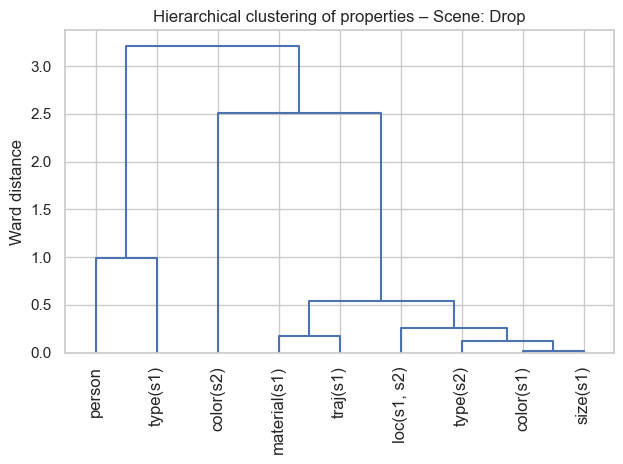

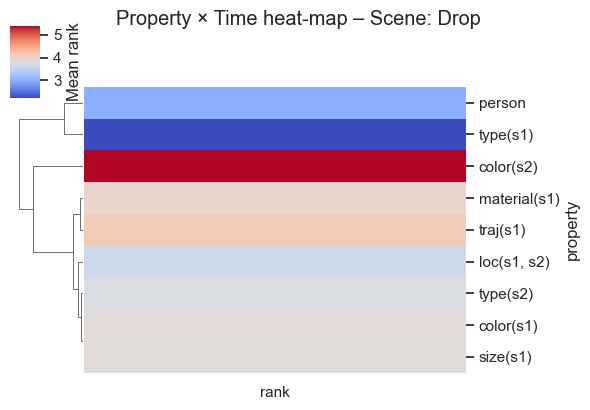

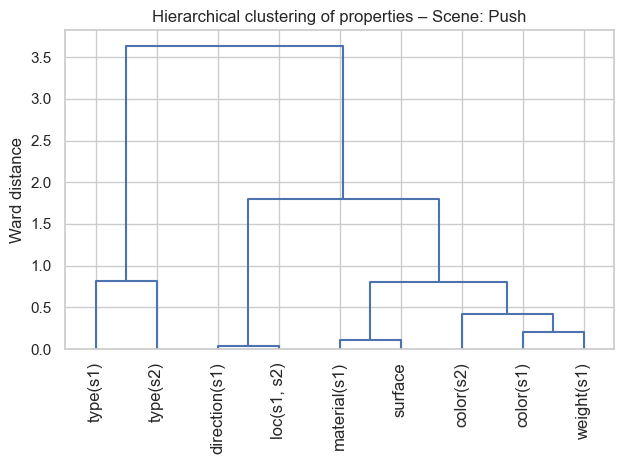

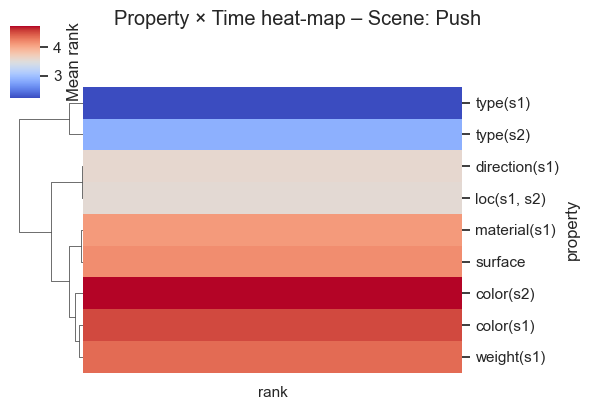

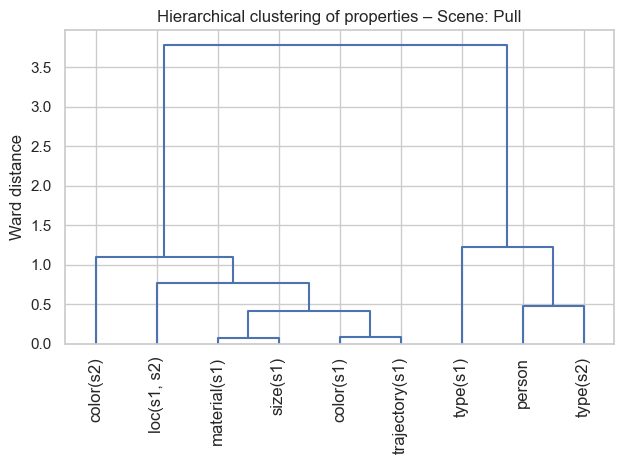

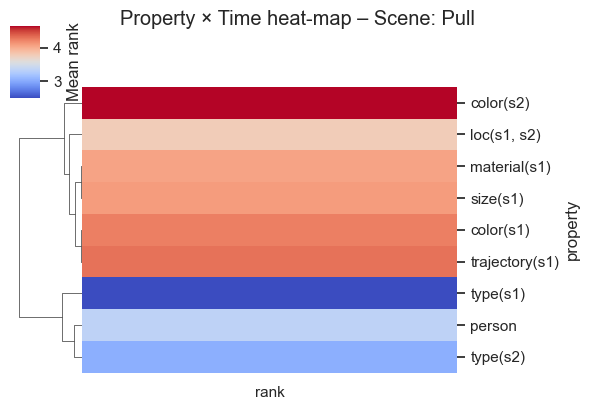

In [55]:
# Unsupervised clustering (hierarchical) of properties *within* each scene
#
# For every scene we:
#   1. Build a feature matrix with rows = properties and
#      columns = experimental “time” conditions (mean rank per property/time).
#   2. Standardise the matrix (z-score per column) so that the clustering is
#      driven by relative patterns, not absolute scale.
#   3. Apply Ward’s hierarchical agglomerative clustering.
#   4. Show both a dendrogram and a heat-map/cluster-map of the result.

sns.set_theme(style="whitegrid")

for scene in scenes:
    # 1.  Prepare feature matrix  (property × time)
    sub = long_df.loc[long_df["scene"] == scene]
    
    # Drop rows (properties) that have any NaN rank values across time conditions.
    sub = sub.dropna(subset=['rank'])
    
    # Mean rank of each property for every time-condition.
    # feat = (sub.pivot_table(index="property", columns="time", values="rank", aggfunc="mean"))
    feat = (sub.pivot_table(index="property", values="rank", aggfunc="mean"))

    # 2.  Standardise (z-score) so Ward distance is not dominated by scale
    scaler = StandardScaler()
    feat_z = scaler.fit_transform(feat)

    # 3.  Hierarchical clustering (Ward)
    Z = linkage(feat_z, method="ward")

    # 4.  Visualisation
    # 4a. Dendrogram
    dendrogram(Z,
               labels=feat.index.tolist(),
               leaf_rotation=90,
               color_threshold=0)      # show full linkage colours
    plt.title(f"Hierarchical clustering of properties – Scene: {scene}")
    plt.ylabel("Ward distance")
    plt.tight_layout()
    plt.show()

    # 4b. Heat-map with clustered rows/columns
    cg = sns.clustermap(feat, row_linkage=Z, col_cluster=False,
                        cmap="coolwarm", figsize=(6, 4),
                        cbar_kws={"label": "Mean rank"},
                        dendrogram_ratio=0.15)
    plt.suptitle(f"Property × Time heat-map – Scene: {scene}", y=1.02)
    plt.show()



## Yes Ratio

                   yes
property              
color(s1)     0.536534
color(s2)     0.363257
loc(s1, s2)   0.776618
material(s1)  0.563674
person        0.384134


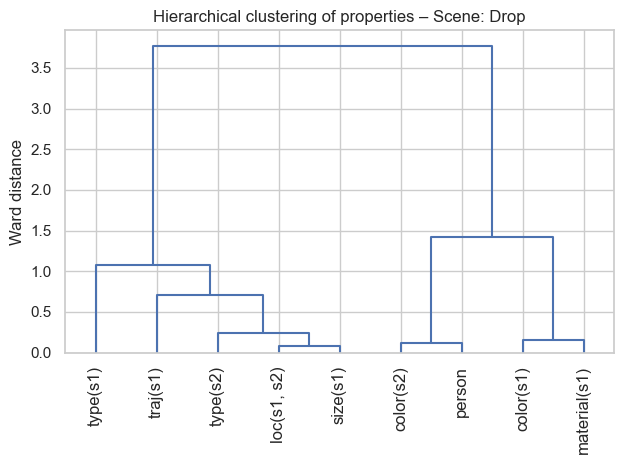

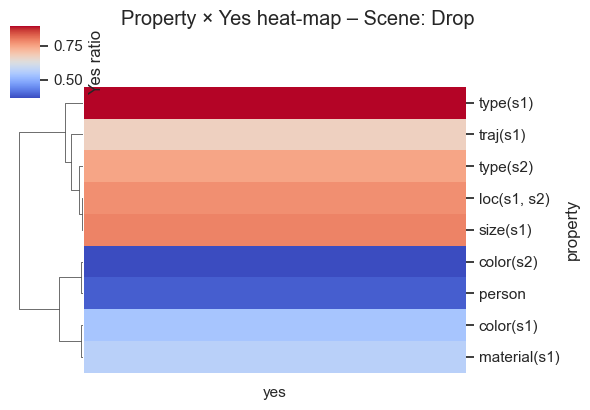

                    yes
property               
color(s1)      0.430041
color(s2)      0.372428
direction(s1)  0.874486
loc(s1, s2)    0.751029
material(s1)   0.621399


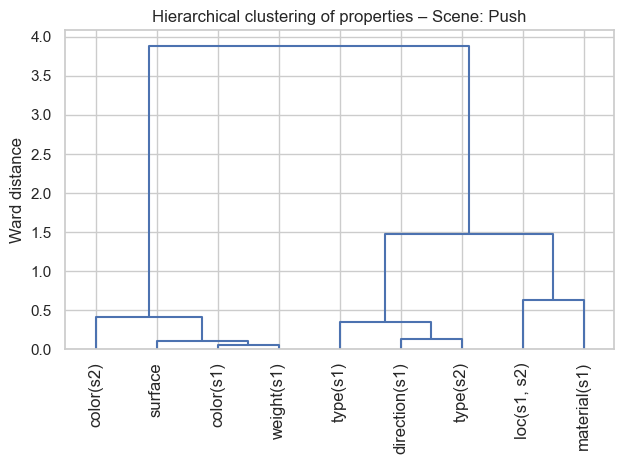

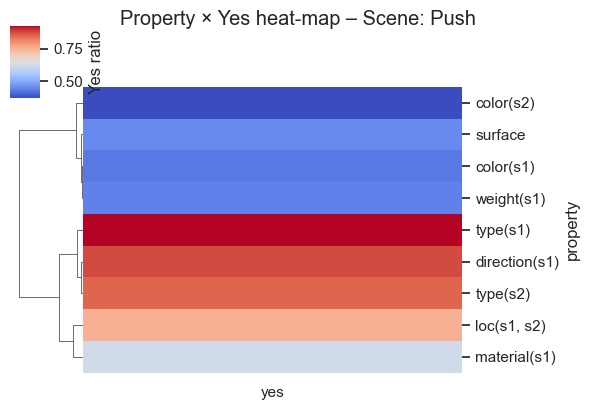

                yes
property           
color(s1)     0.518
color(s2)     0.456
loc(s1, s2)   0.638
material(s1)  0.618
person        0.512


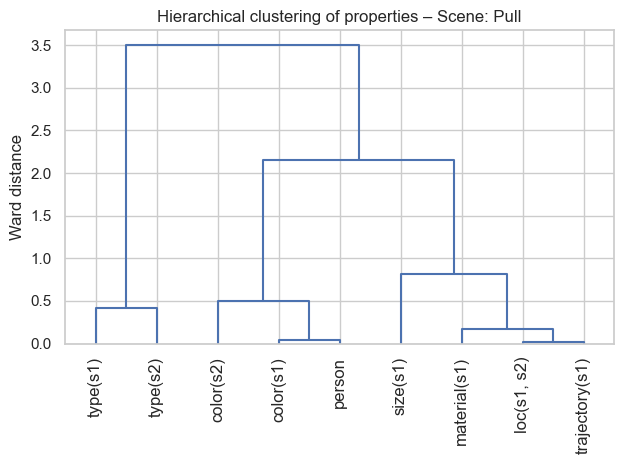

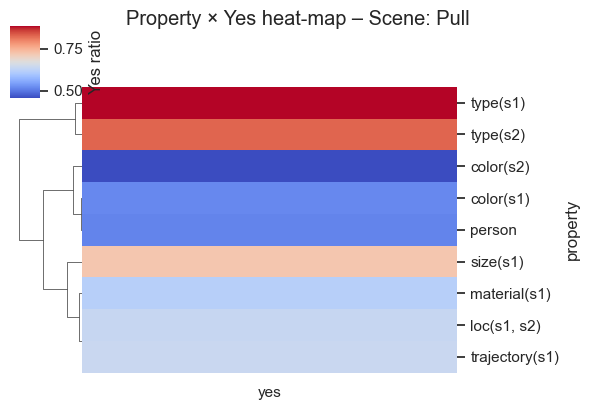

In [44]:
sns.set_theme(style="whitegrid")

for scene in scenes:
    # 1.  Prepare feature matrix  (property × time)
    sub = long_df.loc[long_df["scene"] == scene]
    
    # Mean rank of each property for every time-condition.
    # feat = (sub.pivot_table(index="property", columns="time", values="yes", aggfunc="mean"))
    feat = (sub.pivot_table(index="property", values="yes", aggfunc="mean"))
    print(feat.head())

    # 2.  Standardise (z-score) so Ward distance is not dominated by scale
    scaler = StandardScaler()
    feat_z = scaler.fit_transform(feat)

    # 3.  Hierarchical clustering (Ward)
    Z = linkage(feat_z, method="ward")

    # 4.  Visualisation
    # 4a. Dendrogram
    dendrogram(Z,
               labels=feat.index.tolist(),
               leaf_rotation=90,
               color_threshold=0)      # show full linkage colours
    plt.title(f"Hierarchical clustering of properties – Scene: {scene}")
    plt.ylabel("Ward distance")
    plt.tight_layout()
    plt.show()

    # 4b. Heat-map with clustered rows/columns
    cg = sns.clustermap(feat, row_linkage=Z, col_cluster=False,
                        cmap="coolwarm", figsize=(6, 4),
                        cbar_kws={"label": "Yes ratio"},
                        dendrogram_ratio=0.15)
    plt.suptitle(f"Property × Yes heat-map – Scene: {scene}", y=1.02)
    plt.show()



## Object 

time      1000ms    2000ms     250ms     500ms
object                                        
Obj1    0.706667  0.706452  0.676667  0.674783
Obj1&2  0.733333  0.806452  0.783333  0.782609
Obj2    0.575000  0.596774  0.512500  0.534783
Person  0.366667  0.362903  0.416667  0.391304


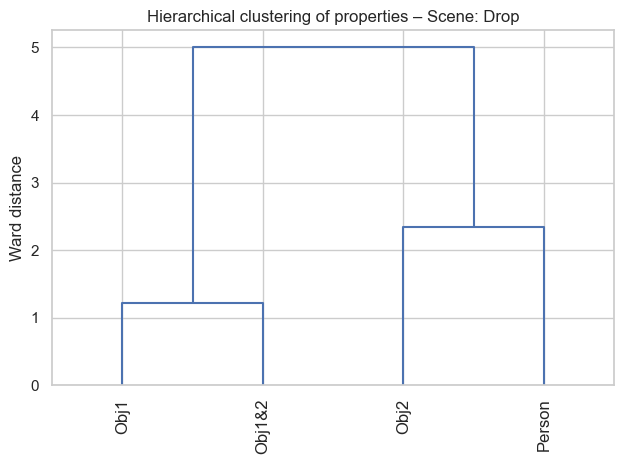

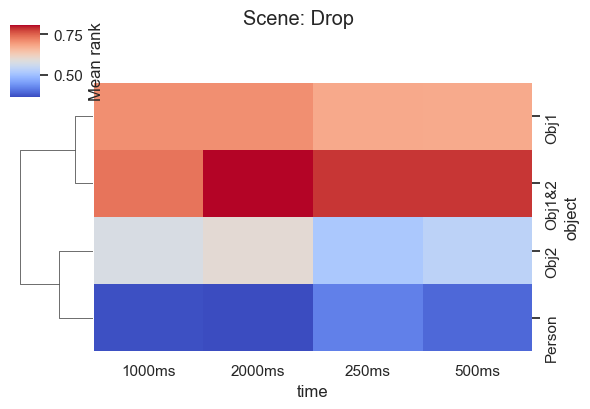

time       1000ms    2000ms   250ms  500ms
object                                    
Obj1     0.647541  0.678992  0.6592  0.645
Obj1&2   0.778689  0.705882  0.7440  0.775
Obj2     0.622951  0.571429  0.6200  0.625
Surface  0.450820  0.487395  0.4240  0.450


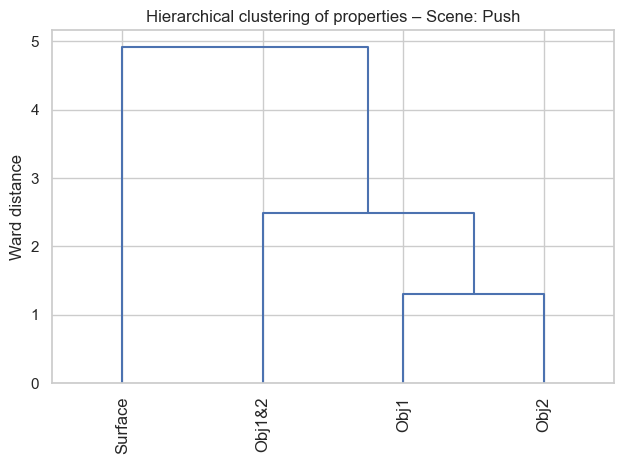

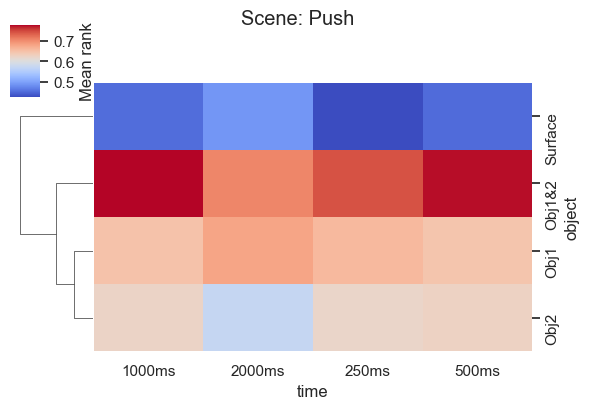

time      1000ms  2000ms     250ms     500ms
object                                      
Obj1    0.701639  0.7104  0.639695  0.660656
Obj1&2  0.655738  0.6080  0.687023  0.598361
Obj2    0.631148  0.6960  0.599237  0.647541
Person  0.475410  0.4960  0.511450  0.565574


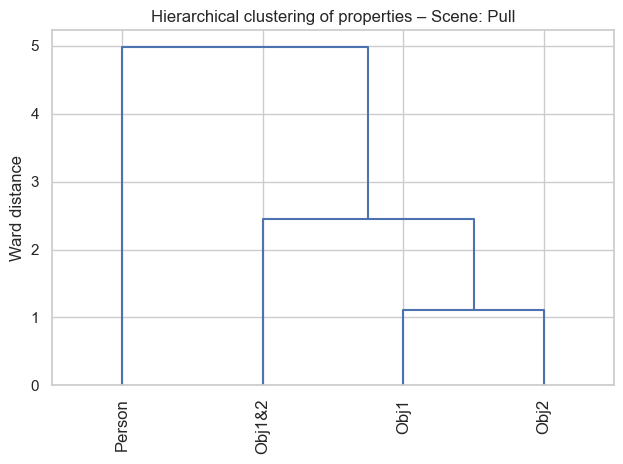

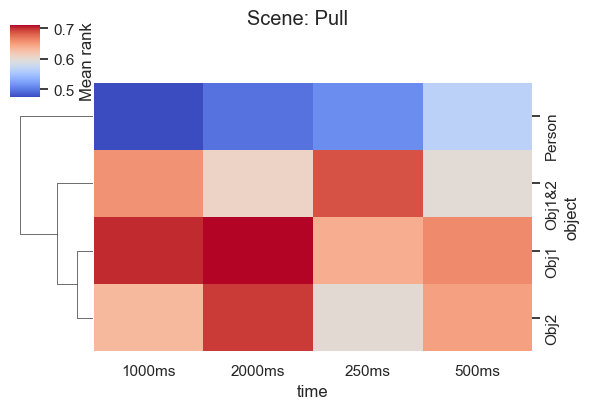

In [57]:
sns.set_theme(style="whitegrid")

for scene in scenes:
    sub = long_df.loc[long_df["scene"] == scene]
    feat = (sub.pivot_table(index="object", columns="time", values="yes", aggfunc="mean"))
    print(feat.head())

    # 2.  Standardise (z-score) so Ward distance is not dominated by scale
    scaler = StandardScaler()
    feat_z = scaler.fit_transform(feat)

    # 3.  Hierarchical clustering (Ward)
    Z = linkage(feat_z, method="ward")

    # 4.  Visualisation
    # 4a. Dendrogram
    dendrogram(Z,
               labels=feat.index.tolist(),
               leaf_rotation=90,
               color_threshold=0)      # show full linkage colours
    plt.title(f"Hierarchical clustering of properties – Scene: {scene}")
    plt.ylabel("Ward distance")
    plt.tight_layout()
    plt.show()

    # 4b. Heat-map with clustered rows/columns
    cg = sns.clustermap(feat, row_linkage=Z, col_cluster=False,
                        cmap="coolwarm", figsize=(6, 4),
                        cbar_kws={"label": "Mean rank"},
                        dendrogram_ratio=0.15)
    plt.suptitle(f"Scene: {scene}", y=1.02)
    plt.show()



time      1000ms    2000ms     250ms     500ms
object                                        
Obj1    3.481132  3.621005  3.443350  3.391753
Obj1&2  3.784091  3.780000  3.223404  3.777778
Obj2    4.557971  4.141892  4.243902  4.219512
Person  2.636364  2.688889  3.320000  3.355556


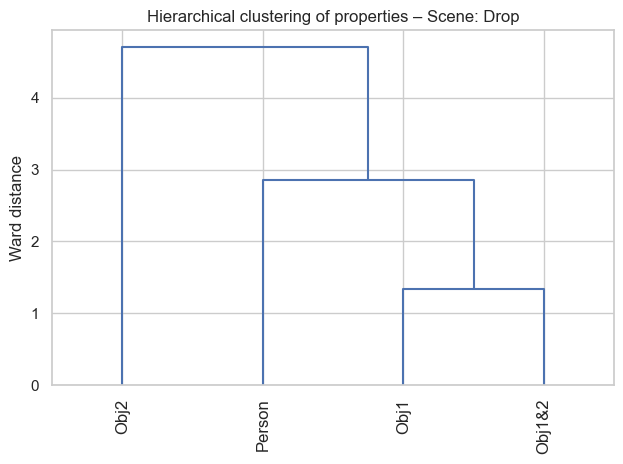

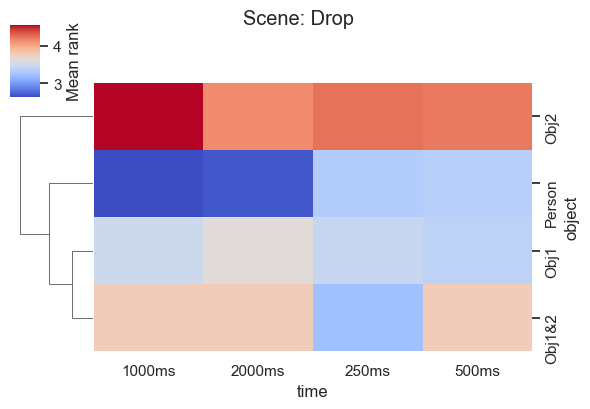

time       1000ms    2000ms     250ms     500ms
object                                         
Obj1     3.615190  3.514851  3.536408  3.428941
Obj1&2   3.547368  3.857143  3.473118  3.333333
Obj2     3.282895  3.330882  3.516129  3.580000
Surface  4.090909  4.000000  4.226415  4.462963


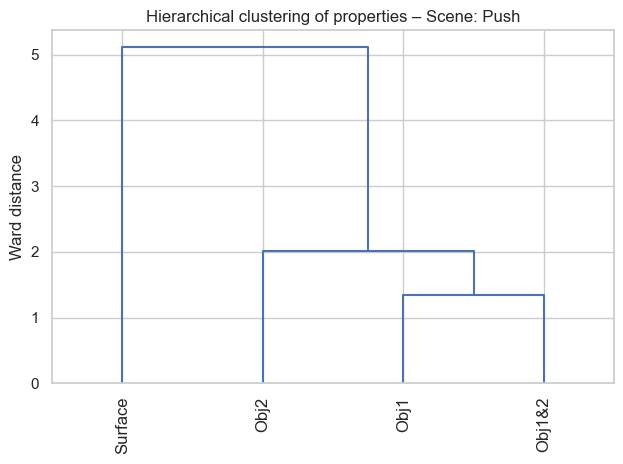

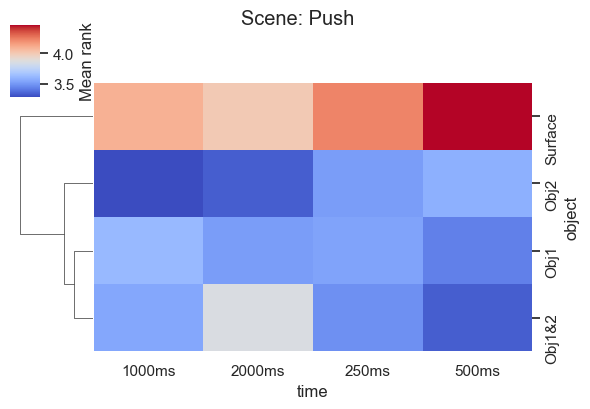

time      1000ms    2000ms     250ms     500ms
object                                        
Obj1    3.679907  3.855856  3.723150  3.657568
Obj1&2  3.962500  3.789474  3.433333  3.986301
Obj2    3.571429  3.649425  3.414013  3.784810
Person  3.931034  3.306452  3.223881  3.014493


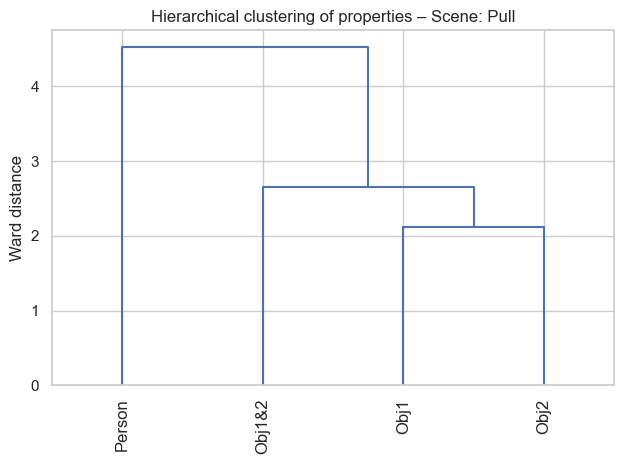

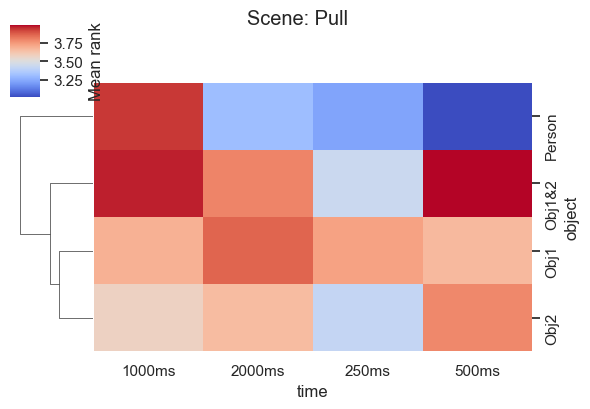

In [58]:
sns.set_theme(style="whitegrid")

for scene in scenes:
    sub = long_df.loc[long_df["scene"] == scene]
    feat = (sub.pivot_table(index="object", columns="time", values="rank", aggfunc="mean"))
    print(feat.head())

    # 2.  Standardise (z-score) so Ward distance is not dominated by scale
    scaler = StandardScaler()
    feat_z = scaler.fit_transform(feat)

    # 3.  Hierarchical clustering (Ward)
    Z = linkage(feat_z, method="ward")

    # 4.  Visualisation
    # 4a. Dendrogram
    dendrogram(Z,
               labels=feat.index.tolist(),
               leaf_rotation=90,
               color_threshold=0)      # show full linkage colours
    plt.title(f"Hierarchical clustering of properties – Scene: {scene}")
    plt.ylabel("Ward distance")
    plt.tight_layout()
    plt.show()

    # 4b. Heat-map with clustered rows/columns
    cg = sns.clustermap(feat, row_linkage=Z, col_cluster=False,
                        cmap="coolwarm", figsize=(6, 4),
                        cbar_kws={"label": "Mean rank"},
                        dendrogram_ratio=0.15)
    plt.suptitle(f"Scene: {scene}", y=1.02)
    plt.show()



# Obj1 vs Obj2

In [55]:
from scipy.stats import kruskal
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests


Mean rank (lower = earlier) with SEM:
 scene  object    n     mean      std      sem
 Drop    Obj1 2395 3.487923 1.860344 0.038014
 Drop  Obj1&2  479 3.639785 2.139181 0.097742
 Drop    Obj2  958 4.291353 2.180136 0.070437
 Drop  Person  479 3.010870 2.200321 0.100535
 Pull    Obj1 2500 3.731405 2.005131 0.040103
 Pull  Obj1&2  500 3.777429 1.970855 0.088139
 Pull    Obj2 1000 3.606532 2.052069 0.064892
 Pull  Person  500 3.347656 2.307752 0.103206
 Push    Obj1 2430 3.524406 1.944848 0.039453
 Push  Obj1&2  486 3.545205 1.763881 0.080011
 Push    Obj2  972 3.430017 1.953577 0.062661
 Push Surface  486 4.190909 2.022682 0.091751
 Drop: Kruskal-Wallis p = nan
      Pair-wise Mann–Whitney U (Holm-corrected):
        Obj1&2 vs Obj1: p_adj = nan (NS)
        Obj1&2 vs Person: p_adj = nan (NS)
        Obj1&2 vs Obj2: p_adj = nan (NS)
        Obj1 vs Person: p_adj = nan (NS)
        Obj1 vs Obj2: p_adj = nan (NS)
        Person vs Obj2: p_adj = nan (NS)
 Push: Kruskal-Wallis p = nan
      Pa

ValueError: cannot reindex on an axis with duplicate labels

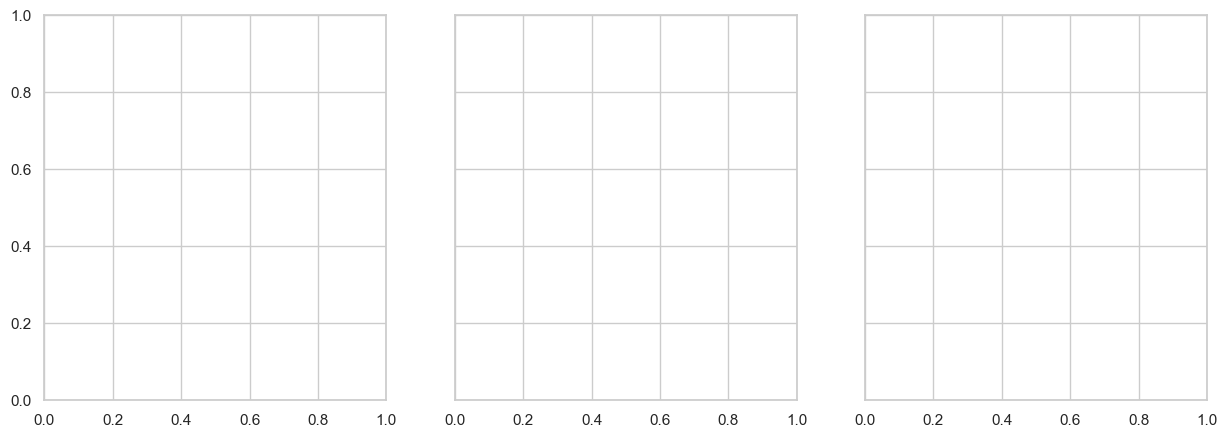

In [56]:
# 2.  Descriptive statistics (mean ± SEM)
stats_df = (
    long_df
    .groupby(["scene", "object"])
    .agg(n=("rank", "size"), mean=("rank", "mean"), std=("rank", "std"))
    .reset_index()
)
stats_df["sem"] = stats_df["std"] / np.sqrt(stats_df["n"])
print("Mean rank (lower = earlier) with SEM:\n", stats_df.to_string(index=False))


# 3.  Omnibus and pair-wise statistics
kw_results: dict[str, float] = {}
pw_results: dict[str, pd.DataFrame] = {}
"""
For each scene the Kruskal-Wallis p-value tests
H₀: all categories come from the same value distribution (same median).
• p < α (e.g. 0.05) → reject H₀ ⇒ at least one object’s typical value differs in that scene.
• p ≥ α → fail to reject H₀ ⇒ no evidence that the objects differ in value.
The test is non-parametric and omnibus; 
a significant result tells “some difference exists” but not which objects differ — 
you’d need follow-up pairwise tests (with correction) to locate the effect.
"""
for s in scenes:                                    # scenes list defined earlier
    df_s = long_df[long_df.scene == s]
    cats  = df_s["object"].unique()

    # --- Kruskal-Wallis omnibus test
    p_kw = np.nan
    if len(cats) > 1:
        _, p_kw = kruskal(*(df_s[df_s.object == c]["rank"] for c in cats))
    kw_results[s] = p_kw
    print(f"{s:>5}: Kruskal-Wallis p = {p_kw:.3g}")

    # --- pair-wise Mann–Whitney U with Holm correction
    pairs, p_raw = [], []
    for i, a in enumerate(cats):
        for b in cats[i + 1 :]:
            _, p = mannwhitneyu(
                df_s.loc[df_s.object == a, "rank"],
                df_s.loc[df_s.object == b, "rank"],
                alternative="two-sided",
            )
            pairs.append((a, b))
            p_raw.append(p)

    if p_raw:                                       # multiple-test correction
        _, p_adj, _, _ = multipletests(p_raw, method="holm")
        pw_df = pd.DataFrame(
            {
                "obj1": [ab[0] for ab in pairs],
                "obj2": [ab[1] for ab in pairs],
                "p_raw": p_raw,
                "p_adj": p_adj,
            }
        )
        pw_df["significance"] = pw_df["p_adj"].apply(p_to_text)
        pw_results[s] = pw_df

        print("      Pair-wise Mann–Whitney U (Holm-corrected):")
        for _, r in pw_df.sort_values("p_adj").iterrows():
            print(f"        {r.obj1} vs {r.obj2}: p_adj = {r.p_adj:.3g} ({r.significance})")

print()  # spacer


# ------------------------------------------------------------------
# 4.  Dot plot (mean ± SEM) with significance annotation
# ------------------------------------------------------------------    
sns.set_theme(style="whitegrid", palette="colorblind")
order = ["Obj1", "Obj2", "Obj1&2", "Person", "Surface"]
all_objs = {v for sc in scenes for v in prop_idx_to_obj[sc].values()}
assert set(order) == all_objs, f"Order mismatch: {set(order)} vs {all_objs}"

fig, axes = plt.subplots(1, len(scenes), figsize=(5 * len(scenes), 5), sharey=True)
if len(scenes) == 1:              # make iterable
    axes = [axes]

for ax, scene in zip(axes, scenes):
    sub = (
        long_df[long_df.scene == scene]
        .set_index("object")
        .reindex(order)
        .dropna()
    )
    x = np.arange(len(sub))
    ax.errorbar(
        x=x,
        y=sub["mean"],
        yerr=sub["sem"],
        fmt="o",
        capsize=4,
        color="tab:blue",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(sub.index, rotation=45)
    ax.set_xlabel("")
    if ax is axes[0]:
        ax.set_ylabel("Average Rank")
    ax.set_title(scene)

    # ---------- annotate significant pair-wise effects
    if scene in pw_results:
        sig_df = pw_results[scene][pw_results[scene].p_adj < 0.05]
        if not sig_df.empty:
            pos = {obj: idx for idx, obj in enumerate(sub.index)}
            start_y = (sub["mean"] + sub["sem"]).max() + 0.25
            step_y  = 0.15
            for _, row in sig_df.sort_values("p_adj").iterrows():
                if row.obj1 in pos and row.obj2 in pos:
                    x1, x2 = pos[row.obj1], pos[row.obj2]
                    y = start_y
                    ax.plot([x1, x1, x2, x2], [y, y + 0.05, y + 0.05, y], lw=1, c="k")
                    ax.text(
                        (x1 + x2) / 2,
                        y + 0.05,
                        row.star,
                        ha="center",
                        va="bottom",
                        fontsize="small",
                    )
                    start_y += step_y

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ------------------------------------------------------------------
# 1.  Data preparation
#     – ensure that every grouping/factor variable is categorical
#     – remove rows with missing data
#     – drop singleton levels that make the random-effect design
#       matrix rank–deficient (a common cause of LinAlgError)
# ------------------------------------------------------------------
cat_vars = ["object", "participant", "scene", "time"]
rank_df = long_df.copy()
rank_df = rank_df.dropna(subset=["rank", *cat_vars]).copy()

for c in ["scene", "time"]:
    counts = rank_df[c].value_counts()
    to_drop = counts[counts < 2].index            # keep only levels seen ≥2×
    rank_df = rank_df[~rank_df[c].isin(to_drop)]

# ------------------------------------------------------------------
# 2.  Model specification
#     Fixed effects : object + category + object × category
#     Random effects: (1 | participant) + (1 | scene) + (1 | time)
# ------------------------------------------------------------------
fe_formula = "rank ~ C(object)"
vc_formula = {
    "participant": "0 + C(participant)",
    "scene": "0 + C(scene)",
}

md = smf.mixedlm(
    fe_formula,
    data=rank_df,
    groups=rank_df["participant"],  
    re_formula="1",                  # random-intercept only
    vc_formula=vc_formula           
)

# ------------------------------------------------------------------
# 3.  Fit the model
#     If LBFGS crashes with a singular‐matrix error, fall back to
#     Powell’s derivative-free optimiser (usually more robust here).
# ------------------------------------------------------------------
try:
    mdf = md.fit(method="lbfgs", maxiter=1000)
except np.linalg.LinAlgError as err:
    print(f"LBFGS failed with a singular matrix ({err}). "
          "Retrying with Powell optimiser …")
    mdf = md.fit(method="powell", maxiter=1000)

print(mdf.summary())

/Users/yichen/opt/anaconda3/envs/pouring/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


LBFGS failed with a singular matrix (Singular matrix). Retrying with Powell optimiser …


/Users/yichen/opt/anaconda3/envs/pouring/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


LinAlgError: Singular matrix

## Avg Rank

Scene Drop one-way ANOVA: f=28.379, p=4.568e-18
Scene Push one-way ANOVA: f=8.919, p=7.028e-06
Scene Pull one-way ANOVA: f=3.138, p=2.442e-02
  scene                        objects  Obj1_avg_rank  Obj1&2_avg_rank  \
0  Drop   [Obj1, Obj1&2, Obj2, Person]       3.487923         3.639785   
1  Push  [Obj1, Obj1&2, Obj2, Surface]       3.524406         3.545205   
2  Pull   [Obj1, Obj1&2, Obj2, Person]       3.731405         3.777429   

   Obj2_avg_rank  Person_avg_rank  Obj1_sem  Obj1&2_sem  Obj2_sem  Person_sem  \
0       4.291353         3.010870  0.045715    0.110911  0.094521    0.162210   
1       3.430017              NaN  0.048652    0.092326  0.080224         NaN   
2       3.606532         3.347656  0.048718    0.110347  0.080926    0.144235   

      f_stat         p_val                                       tukey_result  \
0  28.378791  4.568285e-18     group1  group2  meandiff   p-adj   lower   ...   
1   8.918819  7.028330e-06     group1   group2  meandiff   p-adj   lower  

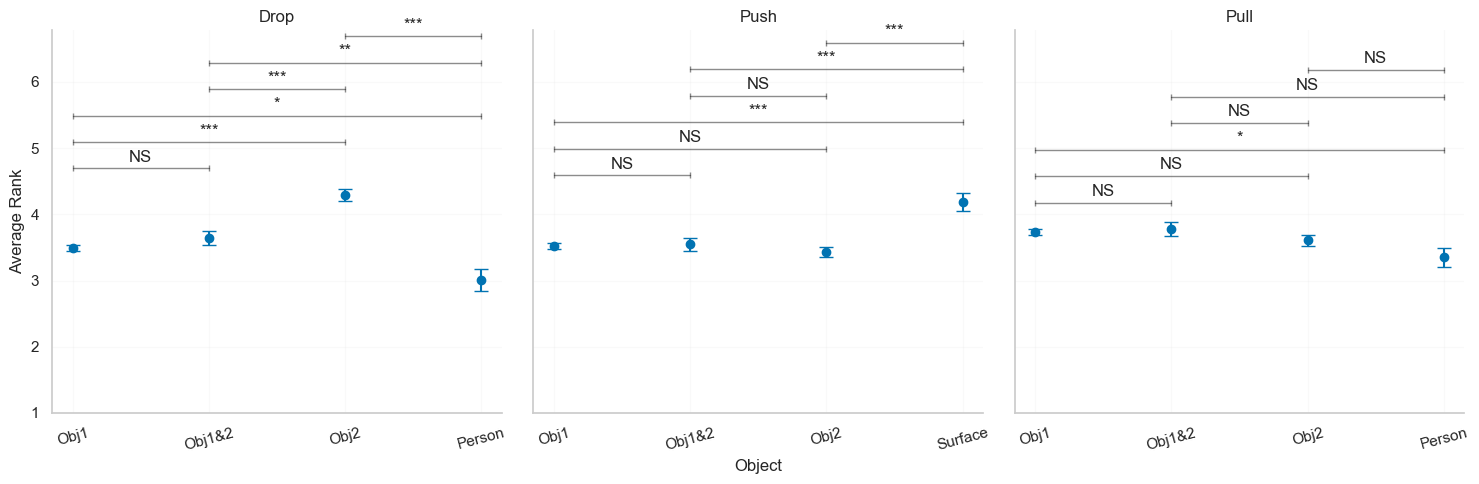

In [57]:
def analyze_object_ranks(df, prop_idx_to_obj=prop_idx_to_obj, property_dict=property_dict, scenes=scenes):
    results = []
    for scene in scenes:
        tmpdf = df[df['scene'] == scene]
        
        objects = sorted(list(set(prop_idx_to_obj[scene].values())))
        obj_ranks = {obj: [] for obj in objects}
        
        # Collect ranks for each property
        for i, (_, vtuple) in enumerate(property_dict[scene].items()):
            (yescol, yesrank, nocol, _, shortname) = vtuple
            rank = tmpdf[tmpdf['property']==shortname].dropna(subset=['rank'])['rank'].tolist()
            obj = prop_idx_to_obj[scene][i]
            obj_ranks[obj].extend(rank)
            
        # Calculate averages and SEMs
        avg_ranks = {
            obj: np.mean(ranks) if ranks else np.nan
            for obj, ranks in obj_ranks.items()
        }
        avg_rank_sems = {
            obj: sem(ranks) if ranks else np.nan
            for obj, ranks in obj_ranks.items()
        }
        
        # Prep data for stats tests
        all_ranks = []
        all_objs = []
        for obj in objects:
            all_ranks.extend(obj_ranks[obj])
            all_objs.extend([obj] * len(obj_ranks[obj]))
        
        # One-way ANOVA
        f_stat, p_val = stats.f_oneway(*[obj_ranks[obj] for obj in objects])
        print(f"Scene {scene} one-way ANOVA: f={f_stat:.3f}, p={p_val:.3e}")
        
        # Post-hoc Tukey test
        mc = MultiComparison(all_ranks, all_objs)
        tukey_result = mc.tukeyhsd()
        
        results.append({
            'scene': scene,
            'objects': objects,
            **{f'{obj}_avg_rank': avg_ranks[obj] for obj in objects},
            **{f'{obj}_sem': avg_rank_sems[obj] for obj in objects},
            'f_stat': f_stat,
            'p_val': p_val,
            'tukey_result': pd.DataFrame(
                    tukey_result._results_table.data[1:],
                    columns=tukey_result._results_table.data[0])
        })
        
    return pd.DataFrame(results)



results_df = analyze_object_ranks(long_df, prop_idx_to_obj, property_dict, scenes)
print(results_df)



# Plotting
fig, axs = plt.subplots(1, len(scenes), figsize=(5 * len(scenes), 5), sharey=True)

for i, scene in enumerate(scenes):
    scene_df = results_df[results_df['scene'] == scene].iloc[0]
    objects = scene_df['objects']
    
    # Get average ranks and SEMs
    avg_ranks = [scene_df[f'{obj}_avg_rank'] for obj in objects]
    sems = [scene_df[f'{obj}_sem'] for obj in objects]
    
    # Plot error bars
    axs[i].errorbar(objects, avg_ranks, yerr=sems, fmt='o', capsize=5, linestyle='')
    
    # Add statistical significance markers
    tukey_result = scene_df['tukey_result']
    y_max = max(avg_ranks) 
    
    # Plot significance bars
    for j, row in tukey_result.iterrows():
        obj1, obj2 = row["group1"], row["group2"]
        idx1, idx2 = idx1, idx2 = objects.index(obj1), objects.index(obj2)
        y_pos = y_max + 0.4 * (j + 1)
        axs[i].plot([idx1, idx2], [y_pos, y_pos], 'k-', lw=1, alpha=0.5, marker='|', markersize=4)
        p_value = row["p-adj"]
        significance = p_to_text(p_value)
        axs[i].text((idx1 + idx2)/2, y_pos + 0.1, significance, ha='center')
    
    # final touch on plot
    axs[i].set_ylim(1, min(y_max + 3, 9))
    axs[i].set_xticks(range(len(objects)))
    axs[i].set_xticklabels(objects, rotation=15)
    axs[i].set_title(f'{scene}')
    axs[0].set_ylabel('Average Rank')
    axs[len(scenes)//2].set_xlabel('Object')
    axs[i].grid(which='both', alpha=0.1)
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['top'].set_visible(False)
    
plt.tight_layout()
plt.show()

## Yes Ratio

Scene Drop one-way ANOVA: f=81.297, p=3.719e-51
Scene Push one-way ANOVA: f=36.127, p=4.683e-23
Scene Pull one-way ANOVA: f=16.976, p=5.815e-11
  scene                        objects  Obj1_avg_yesratio  \
0  Drop   [Obj1, Obj1&2, Obj2, Person]           0.691441   
1  Push  [Obj1, Obj1&2, Obj2, Surface]           0.657613   
2  Pull   [Obj1, Obj1&2, Obj2, Person]           0.677600   

   Obj1&2_avg_yesratio  Obj2_avg_yesratio  Person_avg_yesratio  Obj1_sem  \
0             0.776618           0.555324             0.384134  0.009440   
1             0.751029           0.610082                  NaN  0.009628   
2             0.638000           0.643000             0.512000  0.009350   

   Obj1&2_sem  Obj2_sem  Person_sem     f_stat         p_val  \
0    0.019051  0.016063    0.022247  81.296880  3.718880e-51   
1    0.019635  0.015652         NaN  36.127068  4.683280e-23   
2    0.021514  0.015159    0.022377  16.976061  5.815440e-11   

                                        tukey_res

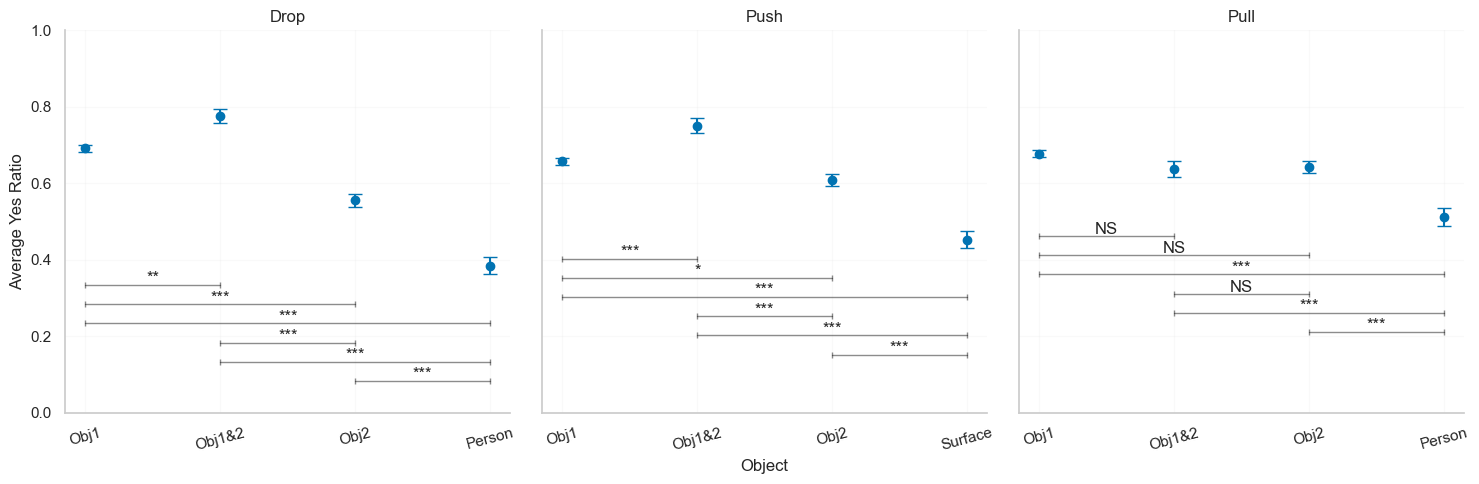

In [58]:
def analyze_object_yesratios(df, prop_idx_to_obj=prop_idx_to_obj, property_dict=property_dict, scenes=scenes):
    results = []
    for scene in scenes:
        tmpdf = df[df['scene'] == scene]
        
        objects = sorted(list(set(prop_idx_to_obj[scene].values())))
        obj_yesratios = {obj: [] for obj in objects}
        
        for i, (_, vtuple) in enumerate(property_dict[scene].items()):
            (_, _, _, _, shortname) = vtuple
            yesratio = tmpdf[tmpdf['property']==shortname].dropna(subset=['yes'])['yes'].tolist()
            obj = prop_idx_to_obj[scene][i]
            obj_yesratios[obj].extend(yesratio)
            
        # Calculate averages and SEMs
        avg_yesratios = {
            obj: np.mean(yesratios) if yesratios else np.nan
            for obj, yesratios in obj_yesratios.items()
        }
        avg_yesratio_sems = {
            obj: sem(yesratios) if yesratios else np.nan
            for obj, yesratios in obj_yesratios.items()
        }
        
        # Prep data for stats tests
        all_yesratios = []
        all_objs = []
        for obj in objects:
            all_yesratios.extend(obj_yesratios[obj])
            all_objs.extend([obj] * len(obj_yesratios[obj]))
        
        # One-way ANOVA
        f_stat, p_val = stats.f_oneway(*[obj_yesratios[obj] for obj in objects])
        print(f"Scene {scene} one-way ANOVA: f={f_stat:.3f}, p={p_val:.3e}")
        
        # Post-hoc Tukey test
        mc = MultiComparison(all_yesratios, all_objs)
        tukey_result = mc.tukeyhsd()
        
        results.append({
            'scene': scene,
            'objects': objects,
            **{f'{obj}_avg_yesratio': avg_yesratios[obj] for obj in objects},
            **{f'{obj}_sem': avg_yesratio_sems[obj] for obj in objects},
            'f_stat': f_stat,
            'p_val': p_val,
            'tukey_result': pd.DataFrame(
                    tukey_result._results_table.data[1:],
                    columns=tukey_result._results_table.data[0])
        })
        
    return pd.DataFrame(results)



results_df = analyze_object_yesratios(long_df, prop_idx_to_obj, property_dict, scenes)
print(results_df)



# Plotting
fig, axs = plt.subplots(1, len(scenes), figsize=(5 * len(scenes), 5), sharey=True)

for i, scene in enumerate(scenes):
    scene_df = results_df[results_df['scene'] == scene].iloc[0]
    objects = scene_df['objects']
    
    # Get average yesratios and SEMs
    avg_yesratios = [scene_df[f'{obj}_avg_yesratio'] for obj in objects]
    sems = [scene_df[f'{obj}_sem'] for obj in objects]
    
    # Plot error bars
    axs[i].errorbar(objects, avg_yesratios, yerr=sems, fmt='o', capsize=5, linestyle='')
    
    # Add statistical significance markers
    tukey_result = scene_df['tukey_result']
    y_min = min(avg_yesratios) 
    
    # Plot significance bars
    for j, row in tukey_result.iterrows():
        obj1, obj2 = row["group1"], row["group2"]
        idx1, idx2 = idx1, idx2 = objects.index(obj1), objects.index(obj2)
        y_pos = y_min - 0.05 * (j + 1)
        axs[i].plot([idx1, idx2], [y_pos, y_pos], 'k-', lw=1, alpha=0.5, marker='|', markersize=4)
        p_value = row["p-adj"]
        significance = p_to_text(p_value)
        axs[i].text((idx1 + idx2)/2, y_pos + 0.005, significance, ha='center')
    
    # final touch on plot
    axs[i].set_ylim(0, 1)
    axs[i].set_xticks(range(len(objects)))
    axs[i].set_xticklabels(objects, rotation=15)
    axs[i].set_title(f'{scene}')
    axs[0].set_ylabel('Average Yes Ratio')
    axs[len(scenes)//2].set_xlabel('Object')
    axs[i].grid(which='both', alpha=0.1)
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['top'].set_visible(False)
    
plt.tight_layout()
plt.show()